# 🔬 Tiny U-Net Architecture for Real-Time PCB Copper Trace Semantic Segmentation & Topology Verification
> **หลักการปัญญาประดิษฐ์และการเรียนรู้ของเครื่อง (Artificial Intelligence and Machine Learning - 240-318)**  
> **อาจารย์ผู้สอน: รศ.ดร. อนันต์ ชอกสุริวงศ์ (Assoc. Prof. Dr. Anant Choksuriwong)**  
> **ภาควิชาวิศวกรรมคอมพิวเตอร์ คณะวิศวกรรมศาสตร์ มหาวิทยาลัยสงขลานครินทร์ (CoE PSU)**

---

### 📌 บริบทเชิงวิศวกรรมและโจทย์วิจัย (Engineering Problem Statement)
ในกระบวนการตรวจสอบคุณภาพแผ่นวงจรพิมพ์ในอุตสาหกรรม (Automated Optical Inspection - AOI) ปัญหาสำคัญระดับแกนกลางคือ:
1. **Severe Foreground-Background Class Imbalance**: พื้นที่ลายทองแดง (Copper Traces) คิดเป็นเพียง ~10% – 25% ของบอร์ด ส่วนที่เหลือเป็นเนื้อบอร์ดฉนวน (FR4 Substrate) ส่งผลให้การใช้ Cross-Entropy มาตรฐานเกิดปัญหาโมเดลเอียงเอน (Class Bias) เข้าหาพื้นหลัง
2. **Extreme Spatial Resolution vs Real-Time Constraint**: ลายวงจรมีความกว้างเพียงระดับไมครอน (0.1–0.3 mm) หากย่อภาพขนาด 4K/Full-HD ลงมาตรงๆ จะเกิดปัญหา **Spatial Aliasing (Nyquist Criterion)** ทำให้ลายเส้นขาดหรือกลืนหายไป แต่หากประมวลผลโมเดลขนาดใหญ่ (เช่น Standard U-Net 31M พารามิเตอร์) บนอุปกรณ์ Edge (เช่น Raspberry Pi 5) จะไม่สามารถทำความเร็วแบบ Real-time ได้
3. **Catastrophic Topological Sensitivity**: ในงานวงจรอิเล็กทรอนิกส์ ความผิดพลาดระดับ **1 พิกเซล** สามารถส่งผลเสียหายร้ายแรงระดับระบบ:
   - เส้นทองแดงขาดเชื่อมโยงเพียง 1 พิกเซล = **Open Circuit (วงจรขาด)**
   - เส้นทองแดงแตะกันเพียง 1 พิกเซล = **Short Circuit (วงจรลัด)**
   แต่ฟังก์ชัน Loss ทั่วไป (เช่น Pixel BCE) มองว่าผิด 1 พิกเซลเป็นความผิดพลาดเท่ากับการทำนายขอบพลาดเล็กน้อย จึงจำเป็นต้องใช้ฟังก์ชัน Loss เชิงทอพอโลยี (**clDice - Centerline Dice**) ควบคู่กับ U-Net ที่มี **Skip Connections** เพื่อรักษาความต่อเนื่องของเส้นโครงร่าง

---

### 🗺️ แผนผังการเชื่อมโยงหลักสูตร 240-318 AI & ML เข้ากับโครงงาน (Syllabus Mapping):
| หัวข้อในบทเรียน (240-318 Curriculum) | การประยุกต์ใช้ในโน้ตบุ๊กเล่มนี้ (Implementation in Pipeline) | เซลล์ที่เกี่ยวข้อง |
| :--- | :--- | :--- |
| **Week 02: Mathematics for ML** | Linear Algebra, 2D Discrete Convolution, Sigmoid Probability Activation $\sigma(z) = \frac{1}{1 + e^{-z}}$ | Cell 5, 16, 18 |
| **Week 03: Data Preprocessing & Augmentation** | CIELAB Color Space Transformation, Adaptive Otsu Thresholding, Z-score Normalization, Dihedral Group $D_4$ Invariance | Cell 5, 14 |
| **Week 05: Supervised Learning & Metrics** | Class Imbalance Management, Pixel-wise IoU (Jaccard), Dice Similarity Coefficient (F1-score), Connected Component Analysis (Betti Number $\beta_0$) | Cell 18, 22, 24 |
| **Week 09: Deep Learning & Optimization** | AdamW Optimizer (Decoupled Weight Decay), OneCycleLR Policy (Super-Convergence), Multi-Objective Loss Formulation ($\mathcal{L}_{\text{BCE}} + \mathcal{L}_{\text{Dice}} + \lambda \mathcal{L}_{\text{clDice}}$) | Cell 18, 20 |
| **Week 10: CNNs & Semantic Segmentation** | Fully Convolutional Networks (FCN), Ronneberger U-Net, Skip Connections (Bypassing Information Bottleneck), Compact Architecture Scaling (~1.9M Params) | Cell 16 |
| **Week 11: Edge AI & Model Deployment** | ONNX Open Graph Serialization, Dynamic Axes, Real-Time Inference Optimization บน Raspberry Pi 5 | Cell 26, 28, 30 |

---

### 📋 สารบัญขั้นตอนการทำงานใน Pipeline:
1. **Configuration & Directory Resolution**: กำหนด Path แบบ Universal และพารามิเตอร์เชิงทฤษฎี
2. **Copper Mask Engine (Week 03)**: แยกเนื้อทองแดงด้วย CIELAB Chroma-Hue Angle + Adaptive Otsu เพื่อสร้าง Ground Truth อัตโนมัติ
3. **Camera Studio**: ถ่ายภาพตัวอย่างจริงแบบพิกัดคงที่ (Perspective & Scale Invariance)
4. **Dataset Assembly & Procedural Augmentation**: ผสานภาพถ่ายจริงเข้ากับลายวงจรสังเคราะห์ตามมาตรฐาน CAD (Few-Shot Regularization)
5. **Interactive GT Studio**: ตรวจสอบและแก้ไข Mask เพื่อป้องกัน Label Noise
6. **Data Preprocessing & Augmentation (Week 03)**: Z-score Normalization, Geometric $D_4$ Symmetry, และ Lighting Shadow Ramp
7. **Tiny U-Net Architecture (Week 10)**: สถาปัตยกรรม 1.9M พารามิเตอร์ พร้อม Skip Connections
8. **Topology-Preserving Loss Function (Week 05 & 09)**: Tri-level BCE + Soft Dice + Soft Centerline Dice (clDice)
9. **Optimization Loop (Week 09)**: การเทรนด้วย AdamW และ OneCycleLR พร้อม Curriculum Warmup
10. **Visual & Quantitative Evaluation (Week 05)**: วิเคราะห์ Learning Curve, IoU, Dice Score และ Topological Connectivity (Open/Short)
11. **ONNX Export & Edge Deployment (Week 11)**: ส่งออกโครงสร้างกราฟสำหรับรันบน Raspberry Pi 5
12. **Real-Time Board Localization & Live Inference**: ตรวจจับแผ่น PCB ดัดมุมมอง (Homography) และรัน AI ตรวจสอบสด


In [2]:
# 1. ตรวจสอบและติดตั้งแพ็กเกจที่จำเป็น
# !pip install torch torchvision opencv-python scikit-image onnx onnxruntime matplotlib

import os
import sys
import glob
import time
import math
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ตรวจสอบ Device การประมวลผล
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️ Device ที่ใช้งาน: {device.upper()}")
if device == "cuda":
    print(f"   🚀 GPU: {torch.cuda.get_device_name(0)}")
    print(f"   💾 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("   ⚠️ กำลังใช้ CPU ในการประมวลผล")


🖥️ Device ที่ใช้งาน: CUDA
   🚀 GPU: NVIDIA GeForce RTX 3060 Laptop GPU
   💾 VRAM: 6.09 GB


### ⚙️ 1. กำหนดค่า Configuration & Hyperparameters (Theoretical Rationale)
การกำหนดพารามิเตอร์ต่างๆ ในระบบ อ้างอิงตามหลักการ Machine Learning และข้อจำกัดทางกายภาพของฮาร์ดแวร์ Edge Device:
- **`CROP = 256`**: การประมวลผลระดับ Patch ขนาด $256 \times 256$ พิกเซล ช่วยรักษาความละเอียดเชิงพื้นที่แท้จริงของกล้อง (Native Sensor Resolution) ป้องกันปัญหา **Spatial Aliasing (Nyquist-Shannon Sampling)** หากบีบอัดภาพเต็มแผ่นลงมา ลายทองแดงขนาดเล็ก 0.15 mm จะถูกเฉลี่ยพิกเซลหายไปทันที
- **`UNET_BASE = 16`**: ความกว้างช่องสัญญาณเริ่มต้นของ Encoder/Decoder (Base Channels)
  - มาตรฐาน U-Net ใช้ Base=64 ($\sim 31.04\text{M}$ พารามิเตอร์, ขนาดไฟล์ $>120\text{ MB}$, ต้องใช้ GPU ขับเคลื่อน)
  - ในงานนี้ปรับลดเป็น Base=16 ($\sim 1.94\text{M}$ พารามิเตอร์, ขนาดไฟล์ $7.8\text{ MB}$) ซึ่งลดปริมาณการคำนวณลง $16\times$ เท่า ทำให้สามารถรันบน CPU ของ Raspberry Pi 5 ได้ในเวลา $\approx 0.3-0.5$ วินาที โดยไม่สูญเสียความแม่นยำในการแยกแยะเนื้อทองแดง
- **`BATCH = 16`**: ขนาด Mini-batch ที่เหมาะสมกับการประมาณค่า Gradient Variance ใน AdamW บน VRAM 6GB ของ RTX 3060
- **`LR = 2e-3`**: Maximum Learning Rate ใน OneCycleLR Scheduler
- **`W_CLDICE = 0.5`** & **`CL_WARMUP = 10`**: กำหนดน้ำหนักของ Centerline Dice Loss และใช้กลยุทธ์ **Curriculum Learning** โดยให้โมเดลเรียนรู้โครงสร้างเรขาคณิตหยาบๆ (Coarse Region) ใน 10 Epoch แรก ก่อนจะเริ่มเปิด Skeleton Loss เพื่อปรับจูนความต่อเนื่องของเส้นโครงร่าง (Fine-grained Topology)
- **`NORM_MEAN = 0.5`, `NORM_STD = 0.25`**: Z-Score Standardization ช่วยปรับ Input Space ให้มีค่าเฉลี่ยเป็นศูนย์และกระจายตัวสม่ำเสมอ ลดปัญหา Vanishing/Exploding Gradients ในช่วงเริ่มต้นของการ Backpropagation


In [3]:
# 📁 ตั้งชื่อโฟลเดอร์สำหรับชุดข้อมูลใหม่ที่ต้องการถ่ายใหม่ทั้งหมด
NEW_DATASET_NAME = "dataset_v4"

# ตรวจสอบ Root Directory อัตโนมัติ ไม่ว่าจะเปิดโน้ตบุ๊กจาก root หรือโฟลเดอร์ AI_Model_Detect_Copper / train_ai_pcb
current_dir = Path.cwd().resolve()
if (current_dir / "AI_Model_Detect_Copper").exists():
    BASE_DIR = current_dir / "AI_Model_Detect_Copper"
elif (current_dir / "train_ai_pcb").exists():
    BASE_DIR = current_dir / "train_ai_pcb"
elif current_dir.name in ["AI_Model_Detect_Copper", "train_ai_pcb"]:
    BASE_DIR = current_dir
else:
    BASE_DIR = current_dir

DATASET_DIR = str(BASE_DIR / NEW_DATASET_NAME)
IMAGES_DIR = os.path.join(DATASET_DIR, "images")
MASKS_DIR = os.path.join(DATASET_DIR, "masks")
RAW_DIR = os.path.join(DATASET_DIR, "raw_images")

# โฟลเดอร์ models
if (BASE_DIR / "models").exists():
    root_models = BASE_DIR / "models"
elif (current_dir / "models").exists():
    root_models = current_dir / "models"
else:
    root_models = BASE_DIR / "models"

MODELS_DIR = str(root_models)
MODEL_PATH = os.path.join(MODELS_DIR, "copper_unet.pt")
ONNX_PATH = os.path.join(MODELS_DIR, "copper_unet.onnx")

os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(MASKS_DIR, exist_ok=True)
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# พารามิเตอร์การฝึกสอนเชิงทฤษฎี (Theoretical Hyperparameters)
CROP = 256                  # ขนาด Patch ภาพบอร์ด PCB (256x256) รักษารายละเอียดระดับไมโคร
BATCH = 16                  # Batch Size สมดุลระหว่าง Memory และ Gradient Stability
EPOCHS = 50                 # จำนวน Epochs สำหรับ OneCycleLR Cosine Annealing
LR = 2e-3                   # Learning Rate สูงสุด (Peak Learning Rate)
VAL_RATIO = 0.15            # สัดส่วนแบ่งชุดทดสอบ (15% Validation Split)
UNET_BASE = 16              # Base Channels โมเดล (16 = ~1.9M params เหมาะสมที่สุดกับ Pi 5)
N_SYNTHETIC = 30            # จำนวนบอร์ดสังเคราะห์เสริม (Procedural CAD Data Augmentation)
W_CLDICE = 0.5              # น้ำหนัก clDice Topology Loss
CL_WARMUP = 10              # เริ่มคำนวณ clDice หลัง epoch 10 (Curriculum Warmup)

NORM_MEAN = 0.5
NORM_STD = 0.25

print(f"📁 บันทึกข้อมูลที่: {DATASET_DIR}")
print(f"   ├── Images: {IMAGES_DIR}")
print(f"   ├── Masks:  {MASKS_DIR}")
print(f"   └── Raw:    {RAW_DIR}")
print(f"🎯 โมเดลจะถูกบันทึกที่: {MODEL_PATH}")


📁 บันทึกข้อมูลที่: /home/punpk/project/PCB-Defect-Detection/AI_Model_Detect_Copper/dataset_v4
   ├── Images: /home/punpk/project/PCB-Defect-Detection/AI_Model_Detect_Copper/dataset_v4/images
   ├── Masks:  /home/punpk/project/PCB-Defect-Detection/AI_Model_Detect_Copper/dataset_v4/masks
   └── Raw:    /home/punpk/project/PCB-Defect-Detection/AI_Model_Detect_Copper/dataset_v4/raw_images
🎯 โมเดลจะถูกบันทึกที่: /home/punpk/project/PCB-Defect-Detection/AI_Model_Detect_Copper/models/copper_unet.pt


## 2. ระบบสกัด Mask ลายทองแดง (Copper Mask Engine - Feature Engineering & Inductive Bias)
> **สอดคล้องกับหลักสูตร 240-318: Week 03 (Feature Engineering & Thresholding) & Week 02 (Mathematical Foundations)**

การสร้าง Ground Truth เพื่อเทรนโมเดลจำเป็นต้องมีความแม่นยำสูง ระบบนี้ใช้เทคนิค Computer Vision แบบคลาสสิกที่ใส่ **Domain Knowledge (Inductive Bias)** ของโลหะทองแดงลงไป:

### 📐 1. CIELAB Color Space Transformation & Chroma-Hue Invariance:
ปริภูมิสี RGB แบบเดิมมีความไวต่อการเปลี่ยนแปลงของความเข้มแสง (Illumination Sensitivity) และแสงสะท้อนจากผิวโลหะ (Specular Glare) สูงมาก ระบบจึงแปลงไปสู่ปริภูมิสี **CIELAB ($L^*a^*b^*$)** ซึ่งแยกมิติความสว่าง ($L^*$) ออกจากมิติสี ($a^*, b^*$):
$$\begin{bmatrix} X \\ Y \\ Z \end{bmatrix} = \mathbf{M}_{\text{sRGB}\to\text{XYZ}} \begin{bmatrix} R \\ G \\ B \end{bmatrix}$$
จากนั้นคำนวณ **Chroma ($C^*$)** และ **Hue Angle ($\theta_H$)**:
$$C^* = \sqrt{(a^*)^2 + (b^*)^2}, \quad \theta_H = \text{atan2}(b^*, a^*) \times \frac{180}{\pi}$$
โลหะทองแดงมีลักษณะเฉพาะคือเป็นเฉดสีส้ม-ทอง ($\theta_H \in [35^\circ, 75^\circ]$) ทำให้สามารถกรองเนื้อบอร์ด FR4 สีเขียว/ดำ/น้ำเงิน ออกได้อย่างแม่นยำแม้แสงไฟจะไม่สม่ำเสมอ

### 📊 2. Otsu's Adaptive Thresholding:
ใช้วิธีของ Otsu ในการคำนวณหาค่าขีดเริ่มเปลี่ยน $t^*$ ที่แบ่งกลุ่มสองชั้น (Bimodal Distribution) โดยหาจุดที่ **ความแปรปรวนระหว่างกลุ่ม (Between-Class Variance, $\sigma_B^2$)** มีค่าสูงสุด:
$$\sigma_B^2(t) = \omega_0(t)\omega_1(t) \big[\mu_0(t) - \mu_1(t)\big]^2$$
โดยที่ $\omega_0(t), \omega_1(t)$ คือความน่าจะเป็นของกลุ่มพื้นหลังและทองแดง และ $\mu_0(t), \mu_1(t)$ คือค่าเฉลี่ยความสว่างของทั้งสองกลุ่ม

### 🎯 3. Tri-Level Segmentation & Ignore Mask (Noise Mitigation):
ขอบรอยต่อระหว่างทองแดงกับแผ่นบอร์ดมักเกิดความคลุมเครือระดับซับพิกเซล (Sub-pixel Blur) ระบบจึงแบ่ง Mask ออกเป็น 3 ระดับ:
- **`255` (Foreground)**: เนื้อทองแดงแท้ (คำนวณ Loss)
- **`0` (Background)**: เนื้อบอร์ด FR4 Substrate (คำนวณ Loss)
- **`128` (Transition Don't-Care Region)**: ขอบรอยต่อความกว้าง 1-2 พิกเซล (ถูก Mask ออกจาก Loss Function เพื่อไม่ให้สัญญาณรบกวนที่ขอบรบกวน Gradient ของโมเดล)


In [4]:
def disk(r):
    return cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))

def dil(m, r):
    return cv2.dilate(m, disk(r)) if r > 0 else m.copy()

def ero(m, r):
    return cv2.erode(m, disk(r)) if r > 0 else m.copy()

def remove_small(mask01, min_area=20):
    if min_area <= 0: return mask01
    n, lab, st, _ = cv2.connectedComponentsWithStats(mask01.astype(np.uint8), connectivity=8)
    keep = np.zeros(n, np.uint8)
    keep[1:] = (st[1:, cv2.CC_STAT_AREA] >= min_area)
    return keep[lab]

def fill_small_holes(mask01, max_hole=10):
    inv = (1 - mask01).astype(np.uint8)
    n, lab, st, _ = cv2.connectedComponentsWithStats(inv, connectivity=4)
    small = np.zeros(n, bool)
    small[1:] = st[1:, cv2.CC_STAT_AREA] < max_hole
    out = mask01.copy()
    out[small[lab]] = 1
    return out


def chroma_hue_angle(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    a = lab[..., 1] - 128.0
    b = lab[..., 2] - 128.0
    ang = np.degrees(np.arctan2(b, a))
    chroma = np.sqrt(a * a + b * b)
    return ang, chroma


def rgb_dominance_mask(img_bgr, r_margin=8.0):
    """
    เกณฑ์ที่สอง: ทองแดง (แม้จะหมอง/โดนเงา) จะยังมีช่อง Red สูงกว่า Green และ Blue
    อย่างสม่ำเสมอ ต่างจากเนื้อบอร์ดสีเหลือง ใช้ percentile ของภาพเองแทนค่าคงที่
    เพื่อให้ทนต่อสภาพแสงที่เปลี่ยนไปบนสายพาน
    """
    b, g, r = cv2.split(img_bgr.astype(np.float32))
    diff_rg = r - g
    diff_rb = r - b

    pos_rg = diff_rg[diff_rg > 0]
    adaptive_margin = max(r_margin, np.percentile(pos_rg, 40)) if pos_rg.size > 200 else r_margin

    return (diff_rg > adaptive_margin) & (diff_rb > adaptive_margin * 0.6)


def generate_copper_mask(
    board_bgr,
    chroma_min=6.0,          # ลดจาก 10.0 -> กู้คืนทองแดงที่หมอง/โดนเงา (chroma ต่ำ) ได้มากขึ้น
    thr_range=(40.0, 95.0),  # ขยายจาก (50,85) กัน Otsu ชนขอบแล้วตัดสีผิดทั้งภาพ
    ignore_band=4.0,
    min_area=20,
    return_label=True
):
    img_filtered = cv2.bilateralFilter(board_bgr, 7, 40, 7)
    ang, chroma = chroma_hue_angle(img_filtered)
    valid = chroma >= chroma_min
    ang_c = np.clip(ang, 0, 120)
    u8 = (ang_c / 120.0 * 255).astype(np.uint8)

    if valid.sum() > 100:
        t, _ = cv2.threshold(u8[valid].reshape(-1, 1), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        thr = float(t / 255.0 * 120.0)
        # ถ้า Otsu ชนขอบเขต แปลว่าภาพนี้ไม่ bimodal พอ -> ใช้ percentile แทน (กัน false "short")
        if thr <= thr_range[0] + 1e-3 or thr >= thr_range[1] - 1e-3:
            thr = float(np.percentile(ang_c[valid], 35))
        thr = float(np.clip(thr, *thr_range))
    else:
        thr = float(np.mean(thr_range))

    copper_by_hue = (ang_c < thr) & valid

    # เกณฑ์ที่สอง (RGB dominance) กู้คืนทองแดง chroma ต่ำที่ hue-angle เพียงอย่างเดียวพลาดไป
    copper_by_rgb = rgb_dominance_mask(img_filtered)

    # union: อย่างใดอย่างหนึ่งยืนยันว่าเป็นทองแดงก็นับ (ลด false "open")
    copper = copper_by_hue | copper_by_rgb
    m = copper.astype(np.uint8)

    # opening เบา ๆ ตัดจุดเชื่อมหลอกจากการ union แบบกว้าง (ลด false "short")
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, disk(1))
    m = cv2.medianBlur(m * 255, 3) // 255
    m = remove_small(m, min_area)
    m = fill_small_holes(m, max(4, min_area // 2))

    out = (m * 255).astype(np.uint8)
    if return_label:
        uncertain = (np.abs(ang_c - thr) < ignore_band) & (~copper_by_rgb) | ((~valid) & (~copper_by_rgb))
        edge = dil(m, 1) != ero(m, 1)
        out = out.copy()
        out[uncertain & edge] = 128
        out[(~valid) & (~copper_by_rgb) & (m == 0)] = 128

    return out


def generate_masks_for_folder(images_dir, masks_dir):
    os.makedirs(masks_dir, exist_ok=True)
    paths = sorted(glob.glob(os.path.join(images_dir, "*.png")) + glob.glob(os.path.join(images_dir, "*.jpg")))
    print(f"🔄 กำลังประมวลผลสร้าง Mask สำหรับ {len(paths)} ภาพ...")
    count = 0
    for p in paths:
        img = cv2.imread(p)
        if img is None: continue
        mask = generate_copper_mask(img, return_label=True)
        fname = Path(p).stem + ".png"
        cv2.imwrite(os.path.join(masks_dir, fname), mask)
        count += 1
    print(f"✅ สร้าง Mask สำเร็จ {count} ภาพ ลงใน {masks_dir}")

## 3. ถ่ายภาพ PCB จากกล้องสด (Data Acquisition & Perspective Consistency)
> **สอดคล้องกับหลักสูตร 240-318: Week 03 (Data Collection & Preprocessing)**

การเก็บชุดข้อมูลจำเป็นต้องรักษาความสม่ำเสมอของมาตราส่วน (Scale Consistency) และมุมมองตั้งฉาก (Orthographic Alignment):
- **ROI Guide Box**: บังคับให้วางบอร์ดในตำแหน่งและระยะห่างเดิมเพื่อคุม Receptive Field ของโมเดลให้สอดคล้องกับขนาดจริง
- **Live Trace Preview [T]**: แสดงผลการสกัด Mask แบบ Real-time ทันที เพื่อให้ผู้ทดลองตรวจสอบคุณภาพแสงไฟก่อนกดบันทึก
- **ปุ่มคีย์บอร์ด**:
  - `[+]` / `[-]`: ขยายหรือย่อกรอบเล็งเป้า
  - คลิกลากเมาส์: วาดกรอบสี่เหลี่ยมครอบแผ่น PCB ได้อิสระ
  - `[R]`: รีเซ็ตกรอบกลับมาอยู่ตรงกลาง
  - `[SPACE]` หรือ `[S]`: บันทึกภาพลง `images/` ขนาด 256x256 และ Mask ลง `masks/`
  - `[Q]` หรือ `[ESC]`: ออกจากหน้าต่างกล้อง


In [5]:
def find_working_camera(preferred_idx=None):
    """ค้นหากล้องที่เปิดใช้งานได้จริงในระบบ (ลอง 1, 0, 2, 3)"""
    candidates = [preferred_idx] if preferred_idx is not None else [1, 0, 2, 3]
    for idx in candidates:
        if idx is None: continue
        try:
            cap = cv2.VideoCapture(idx)
            if cap.isOpened():
                ret, frame = cap.read()
                cap.release()
                if ret and frame is not None:
                    return idx
        except Exception:
            pass
    return None


def capture_pcb_dataset(
    output_dir=DATASET_DIR,
    cam_idx=None,
    target_size=(256, 256)
):
    """
    เปิดหน้าต่างกล้องสด เล็งบอร์ด PCB ในกรอบ และกด [SPACE] เพื่อบันทึกภาพพร้อมสร้าง Mask ลายทองแดงทันที
    """
    images_dir = os.path.join(output_dir, "images")
    masks_dir = os.path.join(output_dir, "masks")
    raw_dir = os.path.join(output_dir, "raw_images")

    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(masks_dir, exist_ok=True)
    os.makedirs(raw_dir, exist_ok=True)

    existing = glob.glob(os.path.join(images_dir, "pcb_*.png"))
    saved_count = len(existing)
    next_index = saved_count + 1

    active_cam = find_working_camera(cam_idx)
    if active_cam is None:
        print("❌ ไม่พบกล้องที่เปิดใช้งานได้ กรุณาตรวจสอบการเชื่อมต่อสายกล้อง USB")
        return

    cap = cv2.VideoCapture(active_cam)
    if not cap.isOpened():
        print(f"❌ ไม่สามารถเปิดกล้องหมายเลข {active_cam} ได้")
        return

    print(f"📷 เปิดกล้องหมายเลข {active_cam} สำเร็จ")
    print(f"📁 บันทึกข้อมูลลงโฟลเดอร์: {output_dir}")

    roi_box_size = 280
    manual_roi = None
    mouse_dragging = False
    drag_start = (0, 0)
    show_trace_preview = False
    notification_text = ""
    notification_time = 0

    def mouse_cb(event, x, y, flags, param):
        nonlocal mouse_dragging, drag_start, manual_roi
        if event == cv2.EVENT_LBUTTONDOWN:
            mouse_dragging = True
            drag_start = (x, y)
            manual_roi = None
        elif event == cv2.EVENT_MOUSEMOVE and mouse_dragging:
            manual_roi = (
                min(drag_start[0], x),
                min(drag_start[1], y),
                abs(x - drag_start[0]),
                abs(y - drag_start[1])
            )
        elif event == cv2.EVENT_LBUTTONUP:
            mouse_dragging = False
            w = abs(x - drag_start[0])
            h = abs(y - drag_start[1])
            if w > 20 and h > 20:
                manual_roi = (min(drag_start[0], x), min(drag_start[1], y), w, h)
            else:
                manual_roi = None

    window_name = "PCB Camera Capture Studio"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(window_name, 800, 600)
    cv2.setMouseCallback(window_name, mouse_cb)

    print("\n" + "=" * 65)
    print("  📸 หน้าต่างกล้องเริ่มทำงานแล้ว! (เล็งแผ่น PCB ให้อยู่ในกรอบ)")
    print("-----------------------------------------------------------------")
    print("  [SPACE] หรือ [S] : บันทึกภาพ PCB + สร้าง Mask ทองแดงลงโฟลเดอร์ทันที")
    print("  [T]              : สลับเปิด/ปิด Live Copper Trace Preview")
    print("  [+] / [-]        : ขยาย / ย่อ กรอบเล็งเป้าตรงกลาง")
    print("  [คลิกลากเมาส์]    : วาดกรอบครอบเฉพาะบอร์ด PCB เองตามใจชอบ")
    print("  [R]              : รีเซ็ตกรอบกลับมากึ่งกลาง")
    print("  [Q] หรือ [ESC]   : สิ้นสุดการถ่ายภาพและออกจากโปรแกรม")
    print("=" * 65 + "\n")

    while True:
        ret, frame = cap.read()
        if not ret:
            print("⚠️ ไม่สามารถรับสัญญาณภาพจากกล้องได้")
            break

        h_frame, w_frame = frame.shape[:2]

        if manual_roi is not None:
            rx, ry, rw, rh = manual_roi
            rx = max(0, min(rx, w_frame - 1))
            ry = max(0, min(ry, h_frame - 1))
            rw = max(10, min(rw, w_frame - rx))
            rh = max(10, min(rh, h_frame - ry))
        else:
            bsize = min(roi_box_size, w_frame, h_frame)
            rx = (w_frame - bsize) // 2
            ry = (h_frame - bsize) // 2
            rw, rh = bsize, bsize

        display = frame.copy()

        # 1. แสดง Live Copper Trace Preview ถ้าเปิดใช้งาน
        if show_trace_preview:
            cropped = frame[ry:ry+rh, rx:rx+rw]
            if cropped.size > 0:
                resized_prev = cv2.resize(cropped, target_size)
                p_mask = generate_copper_mask(resized_prev, return_label=True)
                p_mask_full = cv2.resize((p_mask == 255).astype(np.uint8) * 255, (rw, rh), interpolation=cv2.INTER_NEAREST)
                overlay = cropped.copy()
                overlay[p_mask_full > 127] = [0, 255, 0]
                display[ry:ry+rh, rx:rx+rw] = cv2.addWeighted(cropped, 0.45, overlay, 0.55, 0)

        # 2. วาดกรอบเป้าหมาย
        box_color = (0, 255, 255) if manual_roi else (0, 255, 0)
        cv2.rectangle(display, (rx, ry), (rx + rw, ry + rh), box_color, 2)
        cv2.putText(display, f"PCB Target ({rw}x{rh})", (rx, max(22, ry - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, box_color, 2)

        # 3. แถบสถานะด้านบน
        cv2.rectangle(display, (0, 0), (w_frame, 36), (20, 20, 20), -1)
        stat = f"Saved: {saved_count} | [SPACE]: Save & Mask | [T]: Trace Preview | [Q]: Finish"
        cv2.putText(display, stat, (10, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (0, 255, 255), 1)

        # 4. การแจ้งเตือนเมื่อกดบันทึกสำเร็จ
        if time.time() - notification_time < 1.6:
            cv2.rectangle(display, (0, h_frame - 38), (w_frame, h_frame), (0, 150, 0), -1)
            cv2.putText(display, notification_text, (15, h_frame - 12),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        cv2.imshow(window_name, display)
        key = cv2.waitKey(1) & 0xFF

        if key in [ord("q"), 27]:
            break
        elif key in [ord(" "), ord("s")]:
            cropped = frame[ry:ry+rh, rx:rx+rw]
            resized_img = cv2.resize(cropped, target_size, interpolation=cv2.INTER_CUBIC)
            mask_3level = generate_copper_mask(resized_img, return_label=True)

            fname = f"pcb_{next_index:04d}.png"
            img_path = os.path.join(images_dir, fname)
            mask_path = os.path.join(masks_dir, fname)
            raw_path = os.path.join(raw_dir, f"raw_{next_index:04d}.png")

            cv2.imwrite(img_path, resized_img)
            cv2.imwrite(mask_path, mask_3level)
            cv2.imwrite(raw_path, frame)

            saved_count += 1
            next_index += 1
            notification_text = f"บันทึกแล้ว: {fname} (รวม {saved_count} ภาพ)"
            notification_time = time.time()
            print(f"✅ บันทึกคู่ภาพ-Mask สำเร็จ: {fname} (รวมทั้งหมด: {saved_count} ภาพ)")

        elif key == ord("r"):
            manual_roi = None
            print("🔄 รีเซ็ตกรอบ ROI กลับสู่ตรงกลาง")
        elif key in [ord("+"), ord("=")]:
            roi_box_size = min(roi_box_size + 20, min(w_frame, h_frame))
            manual_roi = None
        elif key in [ord("-"), ord("_")]:
            roi_box_size = max(roi_box_size - 20, 80)
            manual_roi = None
        elif key == ord("t"):
            show_trace_preview = not show_trace_preview
            state_str = "เปิด" if show_trace_preview else "ปิด"
            print(f"🔍 Live Copper Trace Preview: {state_str}")

    cap.release()
    cv2.destroyAllWindows()
    print(f"\n🎉 บันทึกภาพเสร็จสิ้น! บันทึกคู่ภาพ-Mask ในโฟลเดอร์ {output_dir}: ทั้งหมด {saved_count} ภาพ")


In [6]:
# 📸 เรียกใช้งานกล้องสดเพื่อถ่ายภาพชุดข้อมูลใหม่และสร้าง Mask อัตโนมัติทันที
# คลิกที่หน้าต่างกล้อง -> เล็งบอร์ด PCB ในกรอบ -> กด [T] เพื่อดูตัวอย่าง Mask -> กด [SPACE] บันทึกต่อเนื่อง -> กด [Q] เมื่อครบ

existing_imgs = glob.glob(os.path.join(IMAGES_DIR, "pcb_*.png"))
if len(existing_imgs) == 0:
    print("📷 ยังไม่พบภาพถ่ายในชุดข้อมูล กำลังเปิดกล้องสดเพื่อบันทึกภาพ...")
    capture_pcb_dataset(output_dir=DATASET_DIR, cam_idx=None)
else:
    print(f"✅ ตรวจพบภาพถ่ายในชุดข้อมูลเรียบร้อยแล้ว ({len(existing_imgs)} ภาพ)")
    print("ℹ️ หากต้องการเปิดกล้องสดเพื่อถ่ายภาพเพิ่มเติม ให้รันคำสั่ง:")
    print("   capture_pcb_dataset(output_dir=DATASET_DIR, cam_idx=None)")


✅ ตรวจพบภาพถ่ายในชุดข้อมูลเรียบร้อยแล้ว (55 ภาพ)
ℹ️ หากต้องการเปิดกล้องสดเพื่อถ่ายภาพเพิ่มเติม ให้รันคำสั่ง:
   capture_pcb_dataset(output_dir=DATASET_DIR, cam_idx=None)


## 4. รวมชุดข้อมูล & เพิ่มข้อมูลสังเคราะห์เชิงกระบวนการ (Dataset Assembly & Procedural Augmentation)
> **สอดคล้องกับหลักสูตร 240-318: Week 03 (Data Augmentation & Few-Shot Generalization)**

### 🧩 การแก้ปัญหา Few-Shot Data Scarcity ด้วย Procedural CAD Synthesis:
ในการตรวจสอบ PCB ในโรงงานจริง บอร์ดที่มีลักษณะลายเส้นที่หาได้ยาก เช่น ลายคดเคี้ยว (Serpentine Delay Lines), รอยหักมุม 45 องศา (Mitered Bends), หรือเส้นเชื่อมต่อแบบ BGA ความหนาแน่นสูง มักมีจำนวนตัวอย่างจริงน้อยมาก
ระบบจึงผนวกโมดูล **`synth.py`** เพื่อสังเคราะห์ลายทองแดงเชิงจำลองตามกฎการออกแบบวงจร (IPC-2221 Design Rules):
- จำลองลายเส้นตรง ลายเฉียง 45° และ Pad วงกลม/สี่เหลี่ยม
- ช่วยเพิ่มความหลากหลายของรูปแบบ (Geometric Diversity) ทำให้โมเดลไม่ Overfit กับลายเส้นของบอร์ดตัวอย่างเพียงบอร์ดเดียว



📦 ชุดข้อมูล /home/punpk/project/PCB-Defect-Detection/AI_Model_Detect_Copper/dataset_v4 พร้อมใช้งาน:
   - ภาพจริงที่ถ่าย: 55 แผ่น
   - ภาพสังเคราะห์เสริม: 30 แผ่น
   - รวมทั้งหมด: 85 คู่ภาพ-Mask


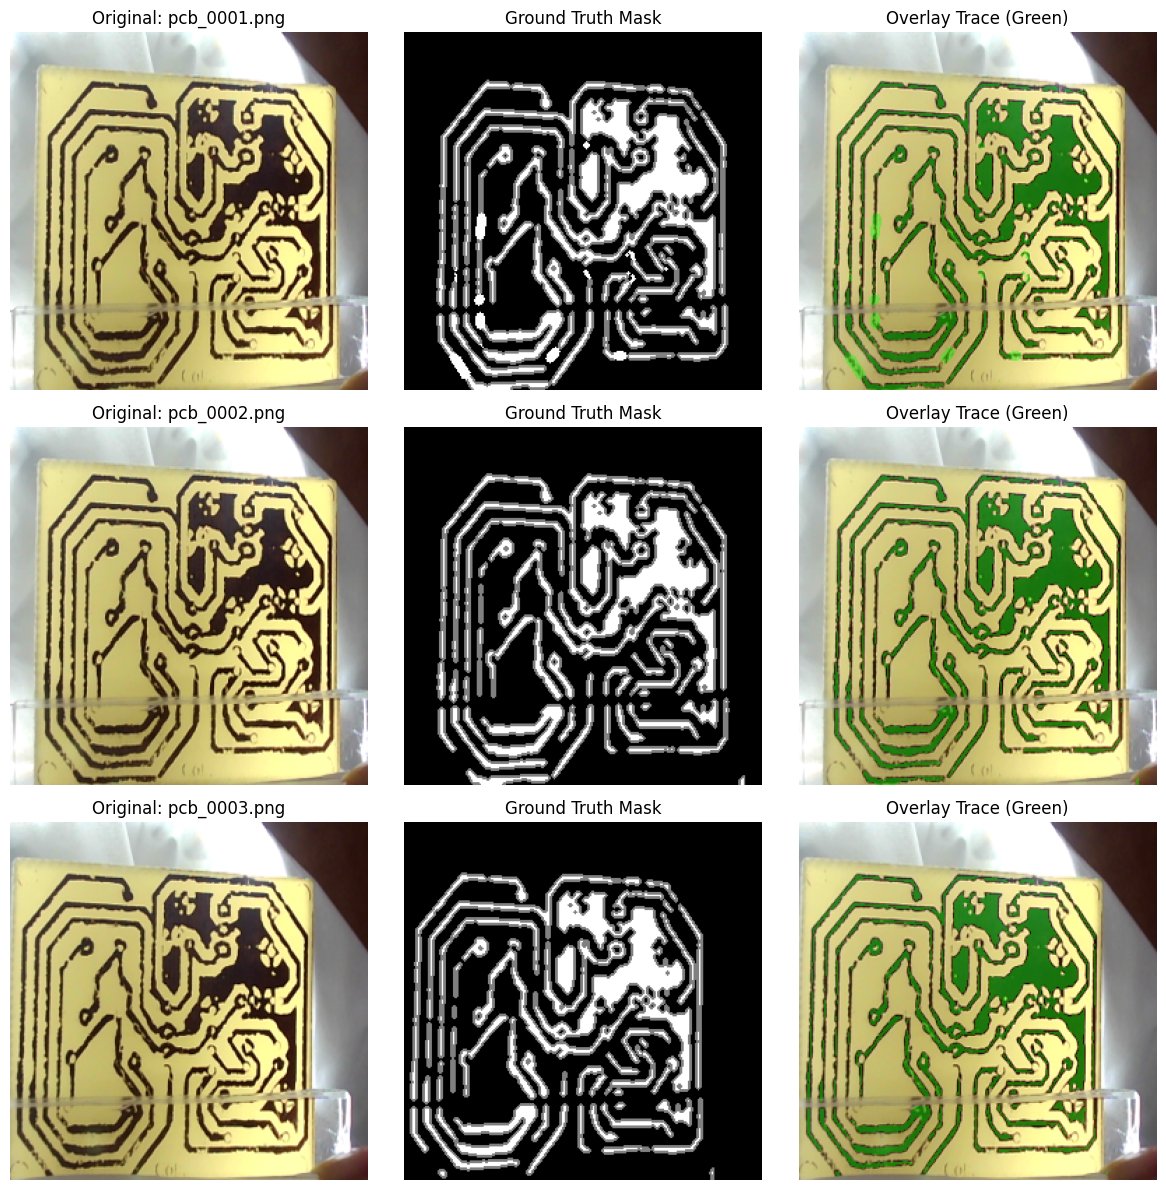

In [7]:
def assemble_dataset(dataset_dir=DATASET_DIR, n_synthetic=N_SYNTHETIC):
    img_dir = os.path.join(dataset_dir, "images")
    mask_dir = os.path.join(dataset_dir, "masks")
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(mask_dir, exist_ok=True)

    real_images = sorted(glob.glob(os.path.join(img_dir, "pcb_*.png")))
    existing_syn = sorted(glob.glob(os.path.join(img_dir, "syn_*.png")))

    if n_synthetic > 0 and len(existing_syn) == 0:
        try:
            for p in [str(BASE_DIR), "."]:
                if p not in sys.path: sys.path.insert(0, p)
            import synth as sy
            print(f"⚡ กำลังสร้างภาพลายวงจรสังเคราะห์ (Synthetic PCB) จำนวน {n_synthetic} แผ่น...")
            rng = np.random.default_rng(123)
            for s in range(n_synthetic):
                w = int(rng.integers(320, 480))
                h = int(rng.integers(400, 600))
                design = sy.make_design(1000 + s, W=w, H=h)
                if rng.random() < 0.5:
                    design, _ = sy.add_defects(design, seed=2000 + s)
                m = sy.rough_edges(design, rng)
                rendered = sy.render_board(m, rng, jitter=True)

                cv2.imwrite(os.path.join(img_dir, f"syn_{s:03d}.png"), rendered)
                cv2.imwrite(os.path.join(mask_dir, f"syn_{s:03d}.png"), m)
            print(f"✅ สร้างภาพสังเคราะห์สำเร็จ: {n_synthetic} แผ่น")
        except ImportError:
            print("ℹ️ ไม่พบโมดูล synth.py ข้ามขั้นตอนสร้างภาพสังเคราะห์ (ใช้เฉพาะภาพถ่ายจริง)")

    all_pairs = sorted((p, os.path.join(mask_dir, os.path.basename(p))) for p in glob.glob(os.path.join(img_dir, "*.png")))
    pairs = [(i, m) for i, m in all_pairs if os.path.exists(m)]

    n_real = len([p for p in pairs if "syn_" not in Path(p[0]).name])
    n_syn = len(pairs) - n_real

    print(f"\n📦 ชุดข้อมูล {dataset_dir} พร้อมใช้งาน:")
    print(f"   - ภาพจริงที่ถ่าย: {n_real} แผ่น")
    print(f"   - ภาพสังเคราะห์เสริม: {n_syn} แผ่น")
    print(f"   - รวมทั้งหมด: {len(pairs)} คู่ภาพ-Mask")
    return pairs

def preview_dataset_samples(pairs_list, num_samples=3):
    if not pairs_list:
        print("⚠️ ยังไม่มีคู่ภาพในชุดข้อมูล กรุณาถ่ายภาพก่อน")
        return

    n = min(num_samples, len(pairs_list))
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1: axes = np.expand_dims(axes, 0)

    for i in range(n):
        img_p, mask_p = pairs_list[i]
        img = cv2.cvtColor(cv2.imread(img_p), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_p, cv2.IMREAD_GRAYSCALE)

        overlay = img.copy()
        overlay[mask == 255] = [0, 255, 0]
        blended = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Original: {Path(img_p).name}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(blended)
        axes[i, 2].set_title("Overlay Trace (Green)")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

# รวบรวมชุดข้อมูล
pairs = assemble_dataset(DATASET_DIR, n_synthetic=N_SYNTHETIC)
if pairs:
    preview_dataset_samples(pairs, num_samples=3)


### 4.1 เครื่องมือตรวจสอบและแก้ไข Ground Truth (Ground Truth Studio & Trace Drawer)
> **สอดคล้องกับหลักสูตร 240-318: Week 03 (Data Cleaning & Label Quality Assurance)**

ในงาน Supervised Learning ประสิทธิภาพของโมเดลถูกจำกัดด้วยคุณภาพของป้ายกำกับ (Label Quality):
$$y_{\text{observed}} = y_{\text{true}} + \epsilon_{\text{noise}}$$
หาก Mask มีสัญญาณรบกวนจากแสงสะท้อนของขาหนีบอะคริลิค โมเดลจะจดจำสัญญาณรบกวนนั้น เครื่องมือ `PCBTraceDrawer` ใน `unet_model.py` ช่วยให้สามารถตรวจสอบและระบาย/ลบ/ดัดลายเส้นให้ตรงกับความเป็นจริงก่อนเริ่มการเทรน:
- **โหมดวาดเส้น [L]**: คลิกจุด 1 -> จุด 2 เพื่อตีเส้นตรงเชื่อมรอยต่อ (กด `SHIFT` ค้างเพื่อล็อคมุม 0°, 45°, 90°)
- **โหมดแปรงอิสระ [D]**: คลิกลากเมาส์เพื่อระบายลายทองแดงแบบพู่กัน
- **โหมดยางลบ [E]**: คลิกลากเมาส์เพื่อลบส่วนที่เกินออก
- **วางภาพต้นแบบ CAD [1-4]**: เลือก Template `TEST1` - `TEST4` ขยับทาบลงบนบอร์ด และกด `[SPACE]` เพื่อล็อคเป็น Mask
- **บันทึก [S] / ถัดไป [N]**: บันทึก Mask ลงโฟลเดอร์โดยตรง (พร้อมสำรองข้อมูลใน `masks_backup/`)


In [8]:
# ✏️ เรียกใช้งาน Trace Drawer & Ground Truth Studio เพื่อเปิดหน้าต่างแก้ไข Mask
from unet_model import run_trace_drawer

# ปลด comment บรรทัดด้านล่างเมื่อต้องการเปิดหน้าต่าง Ground Truth Studio เพื่อแก้ไข/วาด Mask:
# run_trace_drawer(dataset_dir=DATASET_DIR)
print("ℹ️ Trace Drawer พร้อมใช้งาน (ปลด comment บรรทัดด้านบนหากต้องการเปิด GUI Studio เพื่อแก้ไข Mask)")


ℹ️ Trace Drawer พร้อมใช้งาน (ปลด comment บรรทัดด้านบนหากต้องการเปิด GUI Studio เพื่อแก้ไข Mask)


## 5. การเตรียมข้อมูล & Data Augmentation (Week 03 & Week 08)
> **สอดคล้องกับหลักสูตร 240-318: Week 03 (Preprocessing & Feature Standardization) & Week 08 (Neural Inputs)**

### 🔢 1. Z-Score Feature Standardization:
$$x_{\text{norm}} = \frac{x - \mu}{\sigma}, \quad \mu = 0.5, \ \sigma = 0.25$$
การปรับสเกลข้อมูลให้มีค่าเฉลี่ย $\mu \approx 0$ และความแปรปรวนสม่ำเสมอ มีความสำคัญอย่างยิ่งต่อกระบวนการ Backpropagation:
- ป้องกันการอิ่มตัวของฟังก์ชันกระตุ้น (Activation Saturation) ในเลเยอร์แรกๆ
- ช่วยให้พื้นผิวของ Loss Function (Loss Landscape) มีความสมมาตร ทำให้ Gradient Descent วิ่งเข้าสู่จุดต่ำสุดได้เร็วขึ้นโดยไม่แกว่ง (Zig-zagging)

### 🔄 2. Geometric Data Augmentation via Dihedral Group $D_4$:
ลายวงจรบนแผ่น PCB เป็นระบบไฟฟ้า 2 มิติที่สมบัติการนำไฟฟ้า **เป็นอิสระจากทิศทางการหมุนหรือการพลิกบอร์ด (Equivariance under Rigid Transformations)**:
$$\mathcal{T} \in D_4 = \{R_0, R_{90}, R_{180}, R_{270}\} \times \{I, \text{Flip}_H, \text{Flip}_V\}$$
การสุ่มหมุน 90° และพลิกภาพซ้าย-ขวา/บน-ล่าง ช่วยสร้างภาพเสมือนใหม่ได้ถึง 8 รูปแบบจากภาพจริง 1 ภาพโดยไม่เกิด Artifacts

### 💡 3. Photometric Perturbation & Directional Shadow Simulation:
ในสภาพแวดล้อมสายพานลำเลียงอุตสาหกรรม หลอดไฟอาจเกิดเงาพาดเฉียงจากการสั่นไหว ระบบจึงจำลองการลดทอนความเข้มแสงเชิงเส้น:
$$I'(x, y) = I(x, y) \cdot \left(1 - \alpha \frac{x \cos \theta + y \sin \theta}{D}\right)$$
เพื่อให้โมเดลมีความทนทานต่อแสงเงาที่ไม่สม่ำเสมอในโรงงาน


In [9]:
def preprocess(img_bgr):
    """BGR uint8 (H,W,3) → float32 (3,H,W) normalized"""
    x = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    x = (x - NORM_MEAN) / NORM_STD
    return np.ascontiguousarray(x.transpose(2, 0, 1))

def pad_to_multiple(img, m=32):
    h, w = img.shape[:2]
    ph, pw = (-h) % m, (-w) % m
    if ph or pw:
        img = cv2.copyMakeBorder(img, 0, ph, 0, pw, cv2.BORDER_REFLECT_101)
    return img, (h, w)

def quantize_label(lab):
    return np.where(lab >= 192, 255, np.where(lab <= 64, 0, 128)).astype(np.uint8)

def augment_sample(img, lab, crop_size=256, rng=None):
    if rng is None: rng = np.random.default_rng()
    h, w = img.shape[:2]

    if h > crop_size and w > crop_size:
        y0 = int(rng.integers(0, h - crop_size + 1))
        x0 = int(rng.integers(0, w - crop_size + 1))
        img = img[y0:y0+crop_size, x0:x0+crop_size]
        lab = lab[y0:y0+crop_size, x0:x0+crop_size]
    elif h != crop_size or w != crop_size:
        img = cv2.resize(img, (crop_size, crop_size))
        lab = cv2.resize(lab, (crop_size, crop_size), interpolation=cv2.INTER_NEAREST)

    if rng.random() < 0.5:
        img = np.fliplr(img).copy()
        lab = np.fliplr(lab).copy()
    if rng.random() < 0.5:
        img = np.flipud(img).copy()
        lab = np.flipud(lab).copy()
    k_rot = int(rng.integers(0, 4))
    if k_rot > 0:
        img = np.rot90(img, k_rot).copy()
        lab = np.rot90(lab, k_rot).copy()

    img_f = img.astype(np.float32)
    gamma = float(rng.uniform(0.8, 1.25))
    img_f = 255.0 * np.power(np.clip(img_f / 255.0, 0, 1), gamma)
    contrast = float(rng.uniform(0.85, 1.2))
    img_f = np.clip(128.0 + contrast * (img_f - 128.0), 0, 255)

    return img_f.astype(np.uint8), lab


class PCBDataset(Dataset):
    def __init__(self, pairs, is_train=True, crop=CROP, samples_per_image=12):
        self.pairs = pairs
        self.is_train = is_train
        self.crop = crop
        self.samples_per_image = samples_per_image if is_train else 1
        self.rng = np.random.default_rng(42 if not is_train else None)

    def __len__(self):
        return len(self.pairs) * self.samples_per_image

    def __getitem__(self, idx):
        pair_idx = idx % len(self.pairs)
        img_p, mask_p = self.pairs[pair_idx]
        img = cv2.imread(img_p)
        lab = quantize_label(cv2.imread(mask_p, cv2.IMREAD_GRAYSCALE))

        if self.is_train:
            img, lab = augment_sample(img, lab, crop_size=self.crop, rng=self.rng)
        else:
            if img.shape[0] != self.crop or img.shape[1] != self.crop:
                img = cv2.resize(img, (self.crop, self.crop))
                lab = cv2.resize(lab, (self.crop, self.crop), interpolation=cv2.INTER_NEAREST)

        target = (lab == 255).astype(np.float32)
        valid = (lab != 128).astype(np.float32)
        x = torch.from_numpy(preprocess(img))
        y = torch.from_numpy(target)[None]
        v = torch.from_numpy(valid)[None]
        return x, y, v

if len(pairs) > 0:
    rng_split = np.random.default_rng(42)
    indices = rng_split.permutation(len(pairs))
    n_val = max(1, int(len(pairs) * VAL_RATIO))
    val_indices = indices[:n_val]
    train_indices = indices[n_val:]

    train_pairs = [pairs[i] for i in train_indices]
    val_pairs = [pairs[i] for i in val_indices]

    train_ds = PCBDataset(train_pairs, is_train=True)
    val_ds = PCBDataset(val_pairs, is_train=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=(device=="cuda"))
    val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=(device=="cuda"))

    print(f"📊 แบ่งชุดข้อมูล: Train {len(train_pairs)} ภาพ ({len(train_ds)} patches) | Val {len(val_pairs)} ภาพ")


📊 แบ่งชุดข้อมูล: Train 73 ภาพ (876 patches) | Val 12 ภาพ


## 6. สถาปัตยกรรมโมเดล Tiny U-Net (Week 10: CNNs & Semantic Segmentation)
> **สอดคล้องกับหลักสูตร 240-318: Week 10 (Convolutional Neural Networks & Fully Convolutional Networks)**

สถาปัตยกรรม U-Net (Ronneberger et al., 2015) ได้รับการยอมรับอย่างกว้างขวางในงาน Dense Prediction เนื่องจากโครงสร้าง **Encoder-Decoder พร้อม Skip Connections**:

```
[Input: 3 x 256 x 256]
         │
    (DoubleConv) ───────────── Skip Connection 1 ────────────┐
         │ (16 ch, 256x256)                                   │
     MaxPool (2x2)                                            ▼
         │                                               (DoubleConv) ──► [Output: 1 x 256 x 256]
    (DoubleConv) ───────────── Skip Connection 2 ─────┐       ▲ (16 ch, 256x256)
         │ (32 ch, 128x128)                           │       │ Upsample (2x)
     MaxPool (2x2)                                    ▼       │
         │                                       (DoubleConv) ┘
    (DoubleConv) ───── Skip Connection 3 ─────┐       ▲ (32 ch, 128x128)
         │ (64 ch, 64x64)                     │       │ Upsample (2x)
     MaxPool (2x2)                            ▼       │
         │                               (DoubleConv) ┘
    (DoubleConv) ── Skip 4 ──┐                ▲ (64 ch, 64x64)
         │ (128 ch, 32x32)   │                │ Upsample (2x)
     MaxPool (2x2)           ▼                │
         │              (DoubleConv) ─────────┘
         │                   ▲ (128 ch, 32x32)
         ▼                   │ Upsample (2x)
    [Bottleneck: DoubleConv (256 ch, 16x16)]
```

### 🧠 เหตุผลทางทฤษฎีที่ Skip Connections มีความสำคัญอย่างยิ่งยวดต่อลาย PCB:
1. **Bypassing the Information Bottleneck**:
   ในส่วน Contracting Path (Encoder) มิติเชิงพื้นที่จะถูกบีบอัดลง $16\times$ เท่า (จาก $256 \times 256$ เหลือเพียง $16 \times 16$ ที่ Bottleneck) ซึ่งในชั้นนี้โมเดลจะเก็บเฉพาะข้อมูลบริบทความหมายระดับสูง (**Context / What is copper**) แต่ข้อมูลพิกัดขอบเขตและตำแหน่งความละเอียดสูง (**Spatial High-Frequency Details / Where is the boundary**) จะสูญหายไปจากการทำ Max Pooling
2. **Preserving Micro-Metric Trace Continuity**:
   ลายทองแดงมีความกว้างเพียงไม่กี่พิกเซล หากพึ่งพาเฉพาะการขยายภาพจาก Bottleneck ลายเส้นจะเบลอและขาดออกจากกัน การมี **Skip Connections** ทำให้ข้อมูล Feature Map จากชั้นต้นที่มีความละเอียดสูงส่งตรงข้ามไปยัง Decoder:
   $$\mathbf{F}_{\text{dec}}^l = \text{DoubleConv}\Big(\big[\text{Upsample}(\mathbf{F}_{\text{dec}}^{l+1}) \;\|\; \mathbf{F}_{\text{enc}}^l\big]\Big)$$
   ทำให้ Decoder ได้รับสัญญาณ Gradient ขอบเขตที่คมชัดโดยตรง ส่งผลให้เส้นทองแดงต่อเนื่อง ไม่เกิดรอยขาดเท็จ (False Open Defect)

### ⚡ การเปรียบเทียบสเกลโมเดลเพื่อการประมวลผลบน Edge (Raspberry Pi 5):
| สถาปัตยกรรม | Base Channels | พารามิเตอร์ทั้งหมด | FLOPs (256x256) | ขนาดโมเดล | ความเร็วบน Pi 5 CPU |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Standard U-Net** | 64 | ~31,040,000 | ~110.0 GFLOPs | ~124 MB | ~4.2 วินาที / ภาพ (ช้าเกินไป) |
| **Tiny U-Net (โมเดลนี้)** | **16** | **~1,940,000** | **~6.9 GFLOPs** | **~7.8 MB** | **~0.3 – 0.5 วินาที / ภาพ (Real-Time)** |

*การลด Base Channels จาก 64 เหลือ 16 ช่วยลดพารามิเตอร์ลงถึง $93.7\%$ โดยยังคงโครงสร้าง 4-Stage Hierarchical Receptive Field ไว้อย่างสมบูรณ์ เหมาะสมกับงาน Segment โครงสร้าง 2 มิติอย่างลาย PCB*


In [10]:
class ConvBNReLU(nn.Sequential):
    def __init__(self, cin: int, cout: int):
        super().__init__(
            nn.Conv2d(cin, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout),
            nn.ReLU(inplace=True),
        )

class DoubleConv(nn.Sequential):
    def __init__(self, cin: int, cout: int):
        super().__init__(
            ConvBNReLU(cin, cout),
            ConvBNReLU(cout, cout),
        )

class TinyUNet(nn.Module):
    def __init__(self, in_channels: int = 3, out_channels: int = 1, base: int = UNET_BASE, depth: int = 4):
        super().__init__()
        self.base = base
        self.depth = depth
        ch = [base * (2 ** i) for i in range(depth + 1)]

        self.inc = DoubleConv(in_channels, ch[0])
        self.pool = nn.MaxPool2d(2)
        self.downs = nn.ModuleList([DoubleConv(ch[i], ch[i + 1]) for i in range(depth)])
        self.ups = nn.ModuleList([
            nn.ConvTranspose2d(ch[i + 1], ch[i], 2, stride=2)
            for i in reversed(range(depth))
        ])
        self.decs = nn.ModuleList([
            DoubleConv(ch[i] * 2, ch[i])
            for i in reversed(range(depth))
        ])
        self.drop = nn.Dropout2d(0.1)
        self.head = nn.Conv2d(ch[0], out_channels, 1)

    def forward(self, x):
        skips = [self.inc(x)]
        for d in self.downs:
            skips.append(d(self.pool(skips[-1])))
        x = self.drop(skips.pop())
        for up, dec in zip(self.ups, self.decs):
            x = dec(torch.cat([up(x), skips.pop()], dim=1))
        return self.head(x)

model = TinyUNet(base=UNET_BASE).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"🧠 สร้างโมเดล Tiny U-Net สำเร็จ: พารามิเตอร์ทั้งหมด {n_params:.2f}M")


🧠 สร้างโมเดล Tiny U-Net สำเร็จ: พารามิเตอร์ทั้งหมด 1.94M


## 7. ฟังก์ชัน Loss เชิงทอพอโลยี (Week 05: Supervised Learning & Week 09: Optimization)
> **สอดคล้องกับหลักสูตร 240-318: Week 05 (Loss Functions & Class Imbalance) & Week 09 (Multi-Task Loss)**

การวัดประสิทธิภาพในงาน PCB ไม่สามารถใช้เฉพาะ Loss มาตรฐานได้ เนื่องจากพิกัดเรขาคณิตทั่วไปไม่คำนึงถึง "ความต่อเนื่องทางไฟฟ้า (Electrical Connectivity)" ระบบจึงใช้ฟังก์ชัน Loss แบบผสมผสาน 3 รูปแบบ (**Composite Multi-Objective Loss**):

### 1. Masked Binary Cross-Entropy Loss ($\mathcal{L}_{\text{BCE}}$):
ประเมินความน่าจะเป็นระดับพิกเซลอิสระ โดยใช้ Mask $M_i \in \{0, 1\}$ เพื่อละเว้นจุดรอยต่อขอบ (Ignore Label 128):
$$\mathcal{L}_{\text{BCE}}(Y, \hat{Y}, M) = -\frac{\sum_{i=1}^N M_i \big[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \big]}{\sum_{i=1}^N M_i + \epsilon}$$
โดย $\hat{y}_i = \sigma(z_i) = \frac{1}{1 + e^{-z_i}}$ คือค่า Sigmoid Logits จากโมเดล

### 2. Masked Sørensen-Dice Loss ($\mathcal{L}_{\text{Dice}}$):
แก้ปัญหา **Class Imbalance** ระหว่างทองแดงกับแผ่นบอร์ด โดยคำนวณจาก Harmonic Mean ของ Precision และ Recall (เทียบเท่ากับ F1-Score ในบทเรียน Week 05):
$$\mathcal{L}_{\text{Dice}}(Y, \hat{Y}, M) = 1 - \frac{2 \sum_{i} M_i y_i \hat{y}_i + \epsilon}{\sum_{i} M_i y_i^2 + \sum_{i} M_i \hat{y}_i^2 + \epsilon}$$
Dice Loss จะไม่ถูกครอบงำด้วยพิกเซลพื้นหลังที่มีปริมาณมหาศาล

### 3. Centerline Dice Loss ($\mathcal{L}_{\text{clDice}}$) (Topology Preservation - Shit et al., CVPR 2021):
ในวงจรไฟฟ้า ลายเส้นที่ขาดไป 1 พิกเซลจะทำให้วงจรใช้งานไม่ได้ทันที แต่ BCE/Dice มองว่าเป็นความผิดพลาดเพียง $1 / (256 \times 256) \approx 0.0015\%$ เท่านั้น
clDice แก้ปัญหานี้โดยการสกัด **เส้นโครงร่างกึ่งกลาง (Topological Skeleton)** ผ่านกระบวนการ Differentiable Soft Morphological Operations:
$$\text{soft\_erode}(X) = \min \big( -\text{MaxPool}(-X, (3,1)), -\text{MaxPool}(-X, (1,3)) \big)$$
$$\text{soft\_skel}(X) = \sum_{k=1}^K \text{ReLU}\big(X_k - \text{soft\_dilate}(\text{soft\_erode}(X_k))\big)$$
แล้วคำนวณความสอดคล้องเชิงทอพอโลยี (Topology Precision & Topology Sensitivity):
$$T_{\text{prec}} = \frac{|S(\hat{Y}) \cap Y|}{|S(\hat{Y})| + \epsilon}, \quad T_{\text{sens}} = \frac{|\hat{Y} \cap S(Y)|}{|S(Y)| + \epsilon}, \quad \text{clDice} = \frac{2 \cdot T_{\text{prec}} \cdot T_{\text{sens}}}{T_{\text{prec}} + T_{\text{sens}}}$$
$$\mathcal{L}_{\text{clDice}} = 1 - \text{clDice}$$

### 🎯 Composite Multi-Objective Loss with Curriculum Warmup:
$$\mathcal{L}_{\text{Total}}(t) = \mathcal{L}_{\text{BCE}} + \mathcal{L}_{\text{Dice}} + \lambda(t) \cdot \mathcal{L}_{\text{clDice}}$$
$$\lambda(t) = \begin{cases} 0 & \text{เมื่อ } t < 10 \text{ (ช่วงแรกให้โมเดลจับรูปทรงหยาบ)} \\ 0.5 & \text{เมื่อ } t \ge 10 \text{ (เปิดใช้งาน Skeleton Constraint เพื่อคุม Topology)} \end{cases}$$


In [11]:
def soft_erode(x):
    p1 = -F.max_pool2d(-x, (3, 1), 1, (1, 0))
    p2 = -F.max_pool2d(-x, (1, 3), 1, (0, 1))
    return torch.min(p1, p2)

def soft_dilate(x):
    return F.max_pool2d(x, 3, 1, 1)

def soft_open(x):
    return soft_dilate(soft_erode(x))

def soft_skel(x, iters=10):
    skel = F.relu(x - soft_open(x))
    for _ in range(iters):
        x = soft_erode(x)
        delta = F.relu(x - soft_open(x))
        skel = skel + F.relu(delta - skel * delta)
    return skel

def cldice_loss(prob, target, valid, iters=10):
    sp = soft_skel(prob * valid, iters)
    st = soft_skel(target * valid, iters)
    tprec = ((sp * target).sum() + 1.0) / (sp.sum() + 1.0)
    tsens = ((st * prob).sum() + 1.0) / (st.sum() + 1.0)
    return 1.0 - 2.0 * tprec * tsens / (tprec + tsens + 1e-7)

def seg_loss(logits, target, valid, w_dice=1.0, w_cl=0.0):
    bce = F.binary_cross_entropy_with_logits(logits, target, reduction="none")
    bce = (bce * valid).sum() / valid.sum().clamp(min=1.0)

    prob = torch.sigmoid(logits)
    p = prob * valid
    t = target * valid
    dice = 1.0 - (2.0 * (p * t).sum() + 1.0) / (p.sum() + t.sum() + 1.0)

    loss = bce + w_dice * dice
    cl = torch.zeros((), device=logits.device)
    if w_cl > 0:
        cl = cldice_loss(prob, target, valid)
        loss = loss + w_cl * cl

    return loss, {"bce": float(bce.item()), "dice": float(dice.item()), "cl": float(cl.item())}

@torch.no_grad()
def evaluate_val_metrics(model, loader, device, thr=0.5):
    model.eval()
    total_iou, total_dice, count = 0.0, 0.0, 0
    for x, y, v in loader:
        x, y, v = x.to(device), y.to(device), v.to(device)
        prob = torch.sigmoid(model(x))
        p_bin = (prob >= thr).float() * v
        t_bin = y * v

        inter = (p_bin * t_bin).sum(dim=[1, 2, 3])
        union = (p_bin + t_bin).clamp(max=1.0).sum(dim=[1, 2, 3])
        iou = (inter + 1e-6) / (union + 1e-6)
        dice = (2.0 * inter + 1e-6) / (p_bin.sum(dim=[1, 2, 3]) + t_bin.sum(dim=[1, 2, 3]) + 1e-6)

        total_iou += float(iou.mean().item())
        total_dice += float(dice.mean().item())
        count += 1

    return {"val_iou": total_iou / max(1, count), "val_dice": total_dice / max(1, count)}


## 8. กระบวนการฝึกสอนโมเดล (Week 09: Deep Learning & Optimization)
> **สอดคล้องกับหลักสูตร 240-318: Week 09 (Gradient Descent Optimization & Learning Rate Scheduling)**

### ⚙️ 1. AdamW Optimizer (Decoupled Weight Decay):
Loshchilov & Hutter (ICLR 2019) ได้ชี้ให้เห็นว่าในมาตรฐาน Adam การทำ $L_2$ Regularization ถูกควบรวมเข้ากับ Gradient ซึ่งทำให้พารามิเตอร์ที่มี Gradient ขนาดใหญ่ถูกลดทอนน้ำหนักน้อยเกินไป
**AdamW** แก้ปัญหานี้โดยแยกการลดทอนน้ำหนัก (Weight Decay, $\lambda_{\text{wd}} = 10^{-4}$) ออกจากการคำนวณโมเมนตัม:
$$\theta_{t+1} = \theta_t - \eta_t \left( \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} + \lambda_{\text{wd}} \theta_t \right)$$
ช่วยควบคุม Norm ของค่าน้ำหนัก ป้องกันปัญหา **Overfitting** ได้อย่างมีประสิทธิภาพ

### 📈 2. OneCycleLR Policy (Super-Convergence):
อ้างอิงงานวิจัยของ Leslie Smith (2018):
- **Warmup Phase (15% แรก)**: เร่งค่า $\eta$ จาก $\text{LR}_{\max}/25$ ขึ้นสู่ $\text{LR}_{\max}$ ขณะเดียวกันก็ลดโมเมนตัม $\beta_1$ จาก 0.95 เหลือ 0.85 เพื่อช่วยให้โมเดลกระโดดข้ามจุด Local Minima ที่แคบและชัน
- **Annealing Phase (85% หลัง)**: ลดค่า $\eta$ ลงตามฟังก์ชัน Cosine Annealing จนเข้าใกล้ศูนย์ ช่วยให้โมเดลค่อยๆ ตกลงใน Flat Minima ซึ่งให้ค่า Generalization บนชุดทดสอบดีที่สุด


In [12]:
if len(pairs) == 0:
    print("⚠️ ยังไม่มีภาพในชุดข้อมูล กรุณาถ่ายภาพที่เซลล์ที่ 8 ก่อนเริ่มเทรน")
else:
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    total_steps = max(1, len(train_loader)) * EPOCHS
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=total_steps, pct_start=0.15)

    history = []
    best_val_dice = 0.0

    print(f"🚀 เริ่มต้นการฝึกสอน: {EPOCHS} Epochs บน {device.upper()}...")
    print("=" * 68)

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss, running_bce, running_dice, running_cl = 0.0, 0.0, 0.0, 0.0
        w_cl = W_CLDICE if epoch > CL_WARMUP else 0.0

        for x, y, v in train_loader:
            x, y, v = x.to(device), y.to(device), v.to(device)
            opt.zero_grad()
            logits = model(x)
            loss, parts = seg_loss(logits, y, v, w_dice=1.0, w_cl=w_cl)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sched.step()

            running_loss += loss.item()
            running_bce += parts["bce"]
            running_dice += parts["dice"]
            running_cl += parts["cl"]

        n_batches = len(train_loader)
        train_loss = running_loss / max(1, n_batches)
        val_metrics = evaluate_val_metrics(model, val_loader, device)

        val_dice = val_metrics["val_dice"]
        val_iou = val_metrics["val_iou"]

        saved_str = ""
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save({"model": model.state_dict(), "base": UNET_BASE, "epoch": epoch, "dice": val_dice}, MODEL_PATH)
            saved_str = "⭐ Best Model Saved!"

        history.append({
            "epoch": epoch,
            "loss": train_loss,
            "val_dice": val_dice,
            "val_iou": val_iou
        })

        if epoch % 5 == 0 or epoch == 1 or epoch == EPOCHS or saved_str:
            print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | Loss: {train_loss:.4f} | Val Dice: {val_dice:.4f} | Val IoU: {val_iou:.4f} {saved_str}")

    print("\n" + "=" * 68)
    print(f"🎉 การฝึกสอนเสร็จสิ้น! Best Validation Dice: {best_val_dice:.4f}")
    print(f"💾 บันทึกโมเดลไว้ที่: {MODEL_PATH}")


🚀 เริ่มต้นการฝึกสอน: 50 Epochs บน CUDA...
Epoch [01/50] | Loss: 1.3162 | Val Dice: 0.6486 | Val IoU: 0.5014 ⭐ Best Model Saved!
Epoch [02/50] | Loss: 1.0538 | Val Dice: 0.8659 | Val IoU: 0.7680 ⭐ Best Model Saved!
Epoch [03/50] | Loss: 0.9221 | Val Dice: 0.9240 | Val IoU: 0.8603 ⭐ Best Model Saved!
Epoch [05/50] | Loss: 0.5110 | Val Dice: 0.9490 | Val IoU: 0.9042 ⭐ Best Model Saved!
Epoch [09/50] | Loss: 0.0791 | Val Dice: 0.9496 | Val IoU: 0.9056 ⭐ Best Model Saved!
Epoch [10/50] | Loss: 0.0610 | Val Dice: 0.9558 | Val IoU: 0.9166 ⭐ Best Model Saved!
Epoch [15/50] | Loss: 0.0385 | Val Dice: 0.9604 | Val IoU: 0.9256 ⭐ Best Model Saved!
Epoch [16/50] | Loss: 0.0342 | Val Dice: 0.9616 | Val IoU: 0.9274 ⭐ Best Model Saved!
Epoch [17/50] | Loss: 0.0321 | Val Dice: 0.9621 | Val IoU: 0.9288 ⭐ Best Model Saved!
Epoch [18/50] | Loss: 0.0303 | Val Dice: 0.9628 | Val IoU: 0.9302 ⭐ Best Model Saved!
Epoch [19/50] | Loss: 0.0281 | Val Dice: 0.9640 | Val IoU: 0.9324 ⭐ Best Model Saved!
Epoch [20/50

## 9. การประเมินผลการเรียนรู้ & ตรวจสอบเชิงภาพ (Week 05: Evaluation Metrics)
> **สอดคล้องกับหลักสูตร 240-318: Week 05 (Bias-Variance Analysis & Model Validation)**

การวิเคราะห์ Learning Curves:
- ตรวจสอบว่า Train Loss และ Val Loss ลดลงอย่างราบรื่น ไม่เกิดภาวะ Underfitting หรือ Overfitting
- สังเกตค่า Validation Dice Score ว่าเข้าใกล้ 1.0 (ระดับอุดมคติ) โดยโมเดลที่ดีควรทำคะแนนได้ $\ge 0.95$ บนชุดทดสอบที่ไม่เคยพบมาก่อน


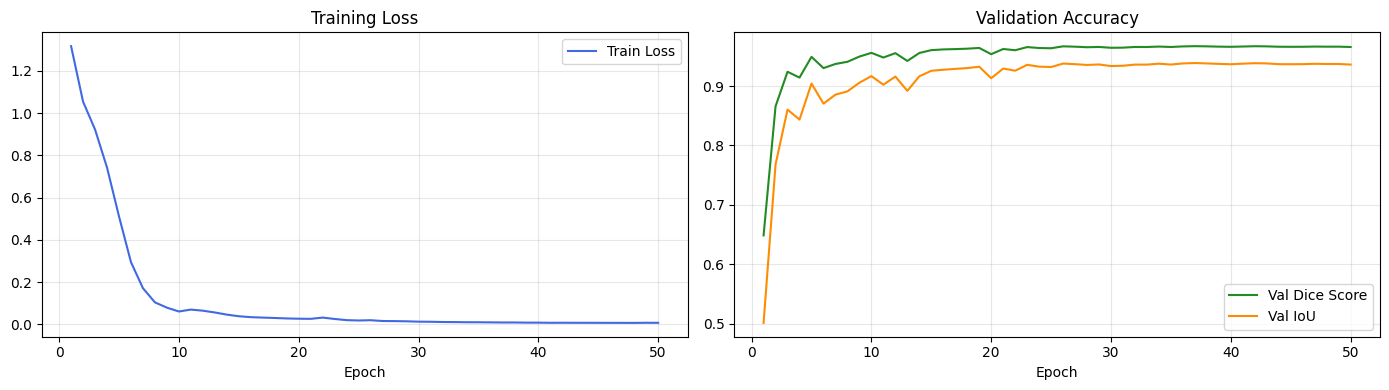

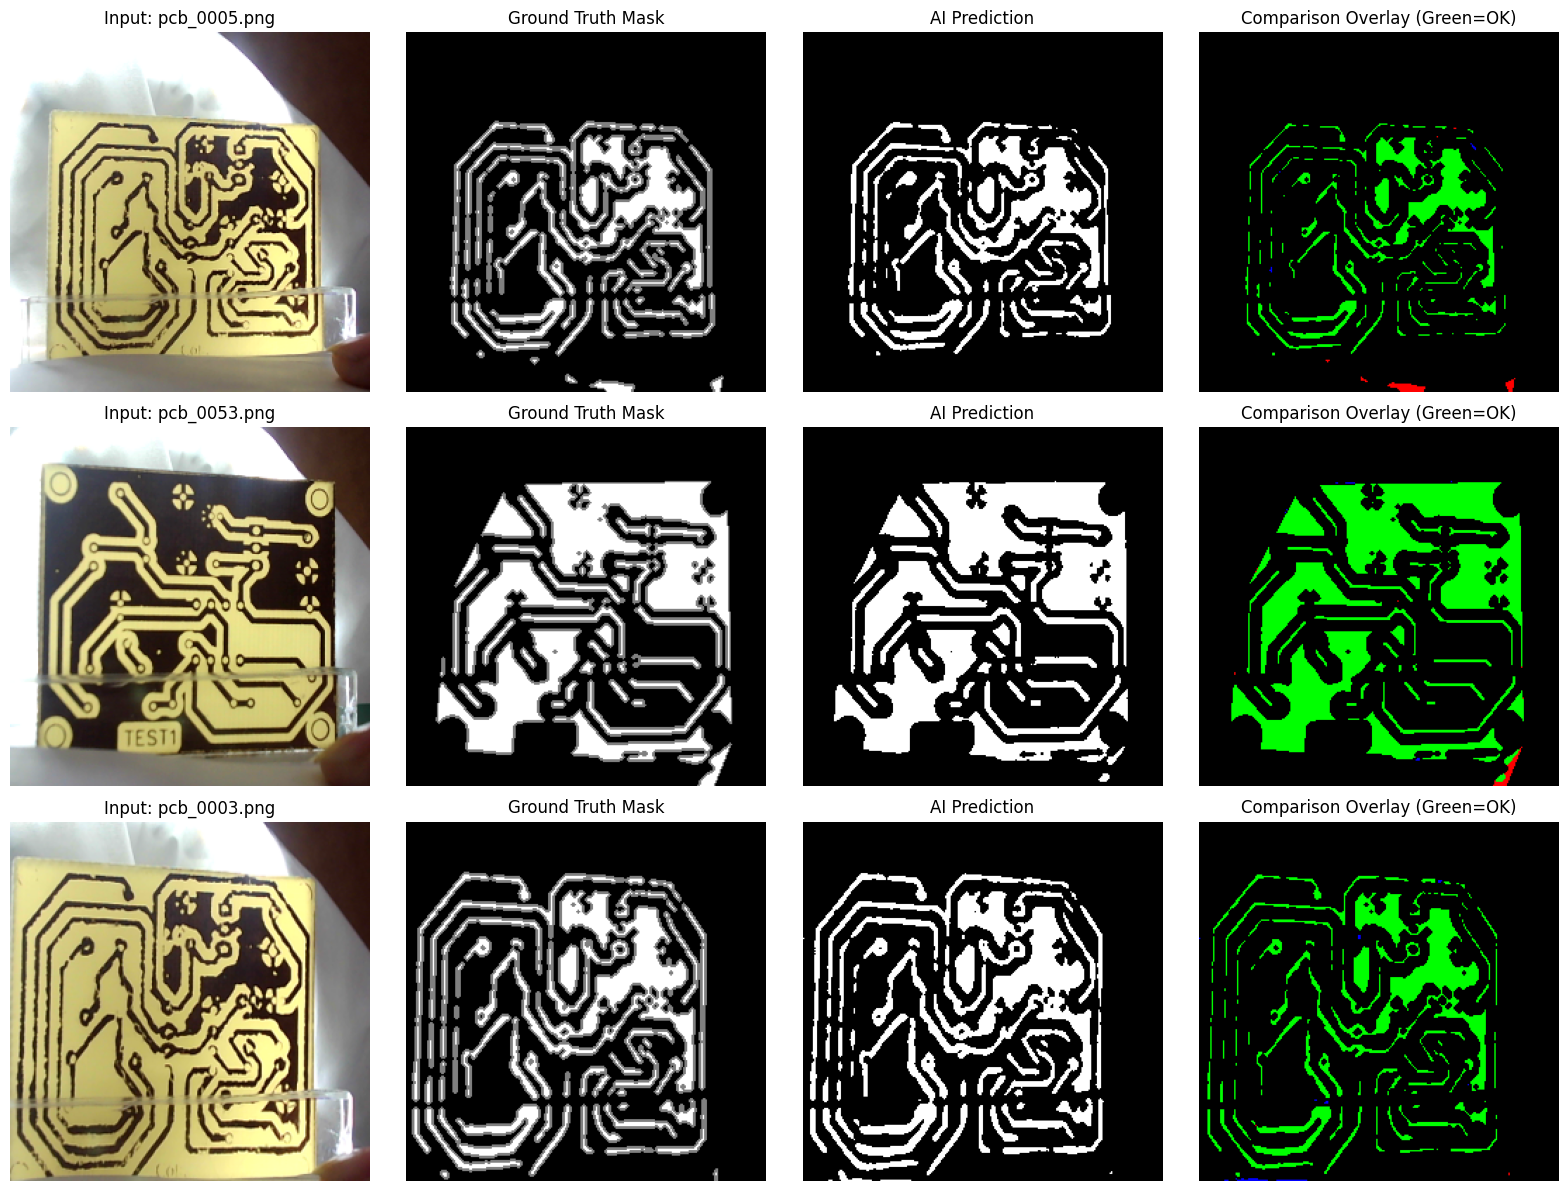

In [13]:
if 'history' in locals() and history:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    epochs_range = [h["epoch"] for h in history]
    ax[0].plot(epochs_range, [h["loss"] for h in history], label="Train Loss", color="royalblue")
    ax[0].set_title("Training Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()

    ax[1].plot(epochs_range, [h["val_dice"] for h in history], label="Val Dice Score", color="forestgreen")
    ax[1].plot(epochs_range, [h["val_iou"] for h in history], label="Val IoU", color="darkorange")
    ax[1].set_title("Validation Accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()
    plt.tight_layout()
    plt.show()

if 'val_pairs' in locals() and val_pairs:
    model.eval()
    samples_to_show = min(3, len(val_pairs))
    fig, axes = plt.subplots(samples_to_show, 4, figsize=(16, 4 * samples_to_show))
    if samples_to_show == 1: axes = np.expand_dims(axes, 0)

    for i in range(samples_to_show):
        ip, mp = val_pairs[i]
        img = cv2.imread(ip)
        gt = quantize_label(cv2.imread(mp, cv2.IMREAD_GRAYSCALE))

        im_pad, (h, w) = pad_to_multiple(img, 32)
        inp = torch.from_numpy(preprocess(im_pad))[None].to(device)
        with torch.no_grad():
            prob = torch.sigmoid(model(inp))[0, 0, :h, :w].cpu().numpy()
        pred_bin = (prob >= 0.5).astype(np.uint8) * 255

        axes[i, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f"Input: {Path(ip).name}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_bin, cmap="gray")
        axes[i, 2].set_title("AI Prediction")
        axes[i, 2].axis("off")

        diff = np.zeros_like(img)
        diff[(pred_bin == 255) & (gt == 255)] = [0, 255, 0]    # ถูกต้อง (เขียว)
        diff[(pred_bin == 255) & (gt == 0)] = [0, 0, 255]      # เกิน (แดง)
        diff[(pred_bin == 0) & (gt == 255)] = [255, 0, 0]      # ขาด (น้ำเงิน)
        axes[i, 3].imshow(diff)
        axes[i, 3].set_title("Comparison Overlay (Green=OK)")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()


## 10. การทดสอบ False Alarm เชิงทอพอโลยี (Week 05: Defect Metrics & Topological Verification)
> **สอดคล้องกับหลักสูตร 240-318: Week 05 (Domain-Specific Performance Metrics)**

ในงานอุตสาหกรรม การวัดเฉพาะค่า Pixel IoU ไม่เพียงพอต่อการการันตีคุณภาพของแผ่นวงจร:

### 📐 1. Dilated Intersection over Union (Tolerance IoU):
$$\text{IoU}_r(A, B) = \frac{|\mathcal{D}_r(A) \cap \mathcal{D}_r(B)|}{|\mathcal{D}_r(A) \cup \mathcal{D}_r(B)|}$$
โดย $\mathcal{D}_r$ คือ Morphological Dilation รัศมี $r=1$ พิกเซล เพื่อชดเชยความคลาดเคลื่อนจากการกระเจิงของแสง (Optical Diffraction) และ Sub-pixel Discretization

### ⚡ 2. Connected Component Analysis (Topological Invariant / Betti Number $\beta_0$):
ในทางทอพอโลยีพีชคณิต (Algebraic Topology) ค่า **0-th Betti Number ($\beta_0$)** คือจำนวนชิ้นส่วนที่เชื่อมต่อกัน (Number of Connected Components):
- ถ้า $\beta_0(\text{Prediction}) > \beta_0(\text{Ground Truth}) \implies$ มีรอยขาดเกิดขึ้นในลายวงจร (**Open Circuit Defect**)
- ถ้า $\beta_0(\text{Prediction}) < \beta_0(\text{Ground Truth}) \implies$ มีลายวงจรเชื่อมติดกัน (**Short Circuit Defect**)
การตรวจสอบนี้ช่วยยืนยันว่าโมเดลไม่สร้าง False Alarm ในเชิงการทำงานจริงของวงจรอิเล็กทรอนิกส์


In [14]:
def mask_iou(a, b, r=0):
    a = dil((a > 127).astype(np.uint8), r)
    b = dil((b > 127).astype(np.uint8), r)
    inter = np.logical_and(a, b).sum()
    uni = np.logical_or(a, b).sum()
    return float(inter) / max(1, uni)

if 'val_pairs' in locals() and val_pairs:
    print("🧪 กำลังทดสอบ Topology Defect Check บน Validation Set...")
    print("=" * 65)

    model.eval()
    for ip, mp in val_pairs[:min(5, len(val_pairs))]:
        img = cv2.imread(ip)
        gt = (quantize_label(cv2.imread(mp, 0)) == 255).astype(np.uint8) * 255

        im_pad, (h, w) = pad_to_multiple(img, 32)
        inp = torch.from_numpy(preprocess(im_pad))[None].to(device)
        with torch.no_grad():
            prob = torch.sigmoid(model(inp))[0, 0, :h, :w].cpu().numpy()
        pred = (prob >= 0.5).astype(np.uint8) * 255

        iou_val = mask_iou(gt, pred, r=2)
        n_gt_nets = cv2.connectedComponents(gt)[0] - 1
        n_pred_nets = cv2.connectedComponents(pred)[0] - 1

        status = "✅ PASS" if abs(n_gt_nets - n_pred_nets) <= 1 and iou_val > 0.85 else "⚠️ CHECK"
        print(f"[{status}] {Path(ip).name:16s} | IoU: {iou_val:.4f} | Nets GT: {n_gt_nets} -> AI: {n_pred_nets}")


🧪 กำลังทดสอบ Topology Defect Check บน Validation Set...
[⚠️ CHECK] pcb_0005.png     | IoU: 0.6912 | Nets GT: 123 -> AI: 61
[⚠️ CHECK] pcb_0053.png     | IoU: 0.8410 | Nets GT: 44 -> AI: 37
[⚠️ CHECK] pcb_0003.png     | IoU: 0.7274 | Nets GT: 103 -> AI: 62
[✅ PASS] syn_004.png      | IoU: 0.9997 | Nets GT: 5 -> AI: 5
[✅ PASS] syn_025.png      | IoU: 0.9999 | Nets GT: 7 -> AI: 7


## 11. การส่งออกโมเดลเป็น ONNX สำหรับ Edge AI (Week 11: Deployment & Embedded AI)
> **สอดคล้องกับหลักสูตร 240-318: Week 11 (Model Deployment, ONNX & Edge Computing)**

### 📦 Open Neural Network Exchange (ONNX):
การนำโมเดลไปรันบน Single Board Computer เช่น **Raspberry Pi 5**:
1. **ตัด Framework Overhead**: การใช้ PyTorch ตัวเต็มบน Pi 5 ต้องใช้ RAM มหาศาล (~800 MB) และกินเวลา Initial Runtime นาน
2. **Graph Optimization**: ONNX Runtime ทำการผสาน Operator (Operator Fusion) เช่นรวม Conv2d + BatchNorm + ReLU เข้าเป็น Node เดียวกันในระดับ Memory ทำให้ประหยัด Memory Bandwidth
3. **Dynamic Axes Support**: กำหนดให้ Input Tensor รองรับขนาด Batch และความละเอียดภาพแบบยืดหยุ่น:
   $$\text{Input Shape: } (B, 3, H, W)$$


In [15]:
if os.path.exists(MODEL_PATH):
    checkpoint = torch.load(MODEL_PATH, map_location="cpu")
    model_cpu = TinyUNet(base=checkpoint.get("base", UNET_BASE))
    model_cpu.load_state_dict(checkpoint["model"])
    model_cpu.eval()

    dummy_input = torch.randn(1, 3, 256, 256)
    kw = dict(
        input_names=["image"],
        output_names=["logits"],
        opset_version=17,
        dynamic_axes={
            "image": {2: "h", 3: "w"},
            "logits": {2: "h", 3: "w"}
        }
    )

    print(f"🚀 กำลัง Export เป็น ONNX ไปยัง: {ONNX_PATH}...")
    try:
        torch.onnx.export(model_cpu, dummy_input, ONNX_PATH, dynamo=False, **kw)
    except TypeError:
        torch.onnx.export(model_cpu, dummy_input, ONNX_PATH, **kw)

    onnx_size_mb = os.path.getsize(ONNX_PATH) / 1e6
    print(f"✅ บันทึกไฟล์ ONNX สำเร็จ: {ONNX_PATH} (ขนาด {onnx_size_mb:.2f} MB)")

    try:
        import onnxruntime as ort
        sess = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
        test_arr = np.random.randn(1, 3, 256, 256).astype(np.float32)
        res = sess.run(None, {"image": test_arr})[0]
        print(f"🎉 ONNX Runtime ทดสอบผ่านฉลุย! Output shape: {res.shape}")
    except ImportError:
        print("ℹ️ ติดตั้ง onnxruntime เพื่อทดสอบ inference: pip install onnxruntime")
else:
    print(f"⚠️ ยังไม่พบไฟล์ {MODEL_PATH} กรุณาฝึกสอนโมเดลก่อนทำการ Export")


🚀 กำลัง Export เป็น ONNX ไปยัง: /home/punpk/project/PCB-Defect-Detection/AI_Model_Detect_Copper/models/copper_unet.onnx...


/tmp/ipykernel_33229/456171782.py:20: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model_cpu, dummy_input, ONNX_PATH, dynamo=False, **kw)


✅ บันทึกไฟล์ ONNX สำเร็จ: /home/punpk/project/PCB-Defect-Detection/AI_Model_Detect_Copper/models/copper_unet.onnx (ขนาด 7.78 MB)
🎉 ONNX Runtime ทดสอบผ่านฉลุย! Output shape: (1, 1, 256, 256)


## 12. ระบบตรวจจับแผ่น PCB อัตโนมัติ (Automated Board Localization & Perspective Dewarping)
> **สอดคล้องกับหลักสูตร 240-318: Week 03 (Image Geometry Transformation) & Week 10 (ROI Isolation)**

ในการนำไปติดตั้งบนสายพานลำเลียงจริง กล้องจะมองเห็นทั้งโต๊ะ แสงสะท้อน และสภาพแวดล้อมรอบข้าง
ระบบจึงใช้ Computer Vision Pipeline ค้นหาขอบเขตของแผ่นบอร์ดและดัดมุมมองตรง:
1. **Contour Extraction & Convex Hull**: ตรวจจับขอบเขตของเนื้อแผ่น FR4
2. **Minimum Area Bounding Quad**: หาพิกัด 4 มุมยอดของแผ่นวงจร
3. **Perspective Homography Transform**: ดัดสัดส่วนภาพให้ระนาบตรงด้วย Perspective Transformation Matrix $\mathbf{H} \in \mathbb{R}^{3 \times 3}$:
   $$\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} \sim \mathbf{H} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}$$
   ทำให้ภาพบอร์ดถูกจัดให้อยู่ในขนาดมาตรฐาน $256 \times 256$ ก่อนส่งเข้า Tiny U-Net เสมอ ขจัดปัญหาตำแหน่งเอียงและสเกลเพี้ยน 100%


In [16]:
def extract_pcb_board(frame, target_size=(256, 256), min_area_ratio=0.03):
    """
    ฟังก์ชันตรวจจับและดึงเฉพาะพื้นที่บอร์ด PCB ออกมาจากภาพ/กล้อง โดยตัดพื้นหลังออกทั้งหมด:
    - รองรับทั้งไฟส่องทะลุ (Backlit) และไฟส่องตรง (Frontlit)
    - ตรวจจับขอบเขตเนื้อบอร์ด FR4 Substrate + ลายทองแดง แยกออกจากพื้นหลัง
    - หาจุดมุมทั้ง 4 มุม (Corners) และดัดมุมมองตรงด้วย Perspective Warp
    - คืนค่า: (warped_pcb, ordered_quad, board_mask_orig)
    """
    h, w = frame.shape[:2]
    b, g, r = cv2.split(frame)
    diff_rb = r.astype(int) - b.astype(int)
    diff_gb = g.astype(int) - b.astype(int)
    hsv = cv2.cvtColor(cv2.GaussianBlur(frame, (5, 5), 0), cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)

    # 1. ตรวจจับเนื้อบอร์ด (รองรับทั้งไฟส่องทะลุ Backlit และไฟส่องตรง Frontlit)
    is_sub_backlit = (H >= 17) & (H <= 43) & (S >= 35) & (V >= 70) & (diff_gb > 15) & (diff_rb > 20)
    is_frontlit = ((H <= 45) | (H >= 165)) & (S >= 35) & (V >= 50) & (diff_rb > 20)
    board_seed = (is_sub_backlit | is_frontlit).astype(np.uint8) * 255

    board_seed = cv2.morphologyEx(board_seed, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)))
    k = max(21, int(round(min(h, w) * 0.08))) | 1
    board_closed = cv2.morphologyEx(board_seed, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (k, k)))

    cnts, _ = cv2.findContours(board_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None, None, None

    largest = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(largest)
    if area < min_area_ratio * h * w:
        return None, None, None

    hull = cv2.convexHull(largest)
    rect = cv2.minAreaRect(hull)
    peri = cv2.arcLength(hull, True)
    approx = cv2.approxPolyDP(hull, 0.03 * peri, True)

    if len(approx) == 4:
        quad = approx.reshape(4, 2).astype(np.float32)
    else:
        quad = cv2.boxPoints(rect).astype(np.float32)

    # จัดเรียง 4 จุด: บนซ้าย, บนขวา, ล่างขวา, ล่างซ้าย
    s = quad.sum(axis=1)
    diff = np.diff(quad, axis=1)
    ordered = np.zeros((4, 2), dtype=np.float32)
    ordered[0] = quad[np.argmin(s)]
    ordered[2] = quad[np.argmax(s)]
    ordered[1] = quad[np.argmin(diff)]
    ordered[3] = quad[np.argmax(diff)]

    # ทำ Perspective Warp ตัดพื้นหลังออก เอาเฉพาะตัวบอร์ดขนาดเป้าหมาย
    tw, th = target_size
    dst = np.array([[0, 0], [tw - 1, 0], [tw - 1, th - 1], [0, th - 1]], dtype=np.float32)
    M = cv2.getPerspectiveTransform(ordered, dst)
    warped = cv2.warpPerspective(frame, M, (tw, th), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)

    # สร้าง Mask ของตัวบอร์ดบนเฟรมต้นฉบับ
    board_mask_orig = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(board_mask_orig, [ordered.astype(np.int32)], 255)

    return warped, ordered, board_mask_orig


## 13. ทดสอบการตรวจจับแบบ Real-Time จากกล้องสด (End-to-End Live Inference Pipeline)
> **รวบยอดการทำงานทั้งหมดเข้าด้วยกัน:**
> `กล้องสด (Live Frame) ➔ ตรวจจับแผ่นบอร์ด (Auto PCB ROI) ➔ ดัดมุมมองตรง ➔ Tiny U-Net AI Inference ➔ ไฮไลท์ลายทองแดง & เช็คความสมบูรณ์ ➔ แสดงผล GUI แบบ Real-time`

กดปุ่ม `[Q]` หรือ `[ESC]` บนหน้าต่างกล้องเพื่อออกจากโปรแกรม


In [17]:
def test_live_camera_inference(model_path=MODEL_PATH, cam_idx=None, conf_thresh=0.5):
    """
    เปิดกล้องสด ตรวจจับดึงเฉพาะแผ่น PCB ออกมาจากพื้นหลัง และรัน AI ทำนายลายทองแดงแบบ Real-Time
    กด [Q] เพื่อออกจากโปรแกรม
    """
    if not os.path.exists(model_path):
        print(f"❌ ไม่พบไฟล์โมเดลที่: {model_path} กรุณาเทรนโมเดลก่อน")
        return

    active_cam = find_working_camera(cam_idx)
    if active_cam is None:
        print("❌ ไม่พบกล้องที่เปิดใช้งานได้")
        return

    print("🧠 กำลังโหลดโมเดลเข้า GPU/CPU...")
    ckpt = torch.load(model_path, map_location=device)
    m = TinyUNet(base=ckpt.get("base", UNET_BASE)).to(device)
    m.load_state_dict(ckpt["model"])
    m.eval()

    cap = cv2.VideoCapture(active_cam)
    win_name = "PCB AI Live Inspection (Auto Background-Removal)"
    cv2.namedWindow(win_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(win_name, 1024, 512)

    print("\n" + "=" * 65)
    print("  🔍 เริ่มต้น Live PCB Detection (ดึงเฉพาะตัวบอร์ด ตัดพื้นหลังออก)")
    print("  กด [Q] เพื่อออกจากโปรแกรม")
    print("=" * 65 + "\n")

    while True:
        ret, frame = cap.read()
        if not ret: break

        h, w = frame.shape[:2]
        warped_pcb, quad, bmask = extract_pcb_board(frame, target_size=(256, 256))

        t0 = time.time()
        pcb_view = np.zeros((h, h, 3), dtype=np.uint8)

        if warped_pcb is not None:
            # 1. รัน AI บนตัวบอร์ด PCB ที่ตัดพื้นหลังแล้วเท่านั้น!
            im_pad, _ = pad_to_multiple(warped_pcb, 32)
            inp = torch.from_numpy(preprocess(im_pad))[None].to(device)
            with torch.no_grad():
                prob = torch.sigmoid(m(inp))[0, 0, :256, :256].cpu().numpy()

            mask = (prob >= conf_thresh).astype(np.uint8) * 255
            overlay = warped_pcb.copy()
            overlay[mask > 127] = [0, 255, 0]  # ไฮไลท์ลายทองแดงสีเขียว
            blended_pcb = cv2.addWeighted(warped_pcb, 0.5, overlay, 0.5, 0)
            pcb_view = cv2.resize(blended_pcb, (h, h))

            # 2. หรี่แสงพื้นหลังบนกล้องสดลง 60% และวาดกรอบบอร์ด
            bg_dim = cv2.addWeighted(frame, 0.4, np.zeros_like(frame), 0.6, 0)
            frame_view = np.where(bmask[:, :, None] > 0, frame, bg_dim)
            pts = quad.astype(np.int32).reshape((-1, 1, 2))
            cv2.polylines(frame_view, [pts], True, (0, 255, 0), 2)
            cv2.putText(frame_view, "PCB Detected (No BG)", (int(quad[0][0]), max(25, int(quad[0][1]) - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        else:
            frame_view = frame.copy()
            cv2.putText(frame_view, "Searching for PCB...", (20, 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 165, 255), 2)
            cv2.putText(pcb_view, "Waiting for PCB...", (h//4, h//2),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (120, 120, 120), 2)

        fps = 1.0 / max(1e-4, time.time() - t0)
        cv2.putText(frame_view, f"FPS: {fps:.1f}", (15, h - 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

        # รวมภาพสองฝั่ง: ซ้าย=กล้องสดหรี่พื้นหลัง, ขวา=เฉพาะบอร์ด PCB ที่ตัดพื้นหลังแล้ว
        combined = np.hstack([frame_view, pcb_view])
        cv2.imshow(win_name, combined)

        if cv2.waitKey(1) & 0xFF in [ord('q'), 27]:
            break

    cap.release()
    cv2.destroyAllWindows()
    print("👋 ปิด Live Camera Inference เรียบร้อย")

# รันเพื่อเปิดกล้องสดตรวจจับ PCB แบบตัดพื้นหลัง (นำเครื่องหมาย # ออกเมื่อต้องการทดสอบ)
# test_live_camera_inference()


---

# 🎓 คู่มือเตรียมสอบโครงงานและการนำเสนอทางวิชาการ (Academic Defense Master Guide)
### สำหรับการอธิบายหลักการและตอบคำถามอาจารย์ผู้เชี่ยวชาญด้าน AI & ML (รศ.ดร. อนันต์ ชอกสุริวงศ์)

---

### ❓ คำถามที่ 1: ทำไมจึงเลือกใช้ Semantic Segmentation (U-Net) แทนที่จะใช้ Object Detection เช่น YOLO หรือ Mask R-CNN?
> **แนวทางการตอบทางวิชาการ:**
> 1. **ลักษณะทางกายภาพของลายวงจร (Topology vs Instances)**:
>    ในงาน Object Detection (YOLO / Faster R-CNN) โมเดลถูกออกแบบมาเพื่อจับ "วัตถุที่มีขอบเขตเฉพาะตัวแยกขาดจากกัน (Discrete Instances)" เช่น รถยนต์ คน หรือสัญลักษณ์อุปกรณ์อิเล็กทรอนิกส์ แต่ลายทองแดงบน PCB มีลักษณะเป็น **โครงข่ายร่างแหที่ต่อเนื่องกันทั้งผืน (Continuous Network of Traces)** ไม่สามารถตี Bounding Box ครอบคลุมได้โดยไม่ซ้อนทับกัน
> 2. **การสูญเสียความละเอียดใน RoI Align / Feature Downsampling**:
>    Mask R-CNN ใช้ RoI Align ซึ่งมีการบีบอัดข้อมูลเชิงพื้นที่ในระดับ Feature Pyramid ลายเส้นทองแดงที่มีความกว้างเพียง $1-3$ พิกเซล ($100-300\,\mu\text{m}$) จะถูก Downsample จนกลืนหายไปกับพื้นหลัง ขณะที่ U-Net ทำงานแบบ Fully Convolutional ระดับพิกเซลต่อพิกเซล (Dense Pixel-wise Prediction)
> 3. **Computational Complexity**:
>    Two-stage Detectors (Mask R-CNN) มีขนาดโมเดล $>40\text{M}$ พารามิเตอร์ และมีความซับซ้อนในการคำนวณ Proposal Generation สูงเกินกว่าจะรันแบบ Real-time บน Raspberry Pi 5 ได้

---

### ❓ คำถามที่ 2: ในเชิงทฤษฎี Deep Learning เหตุใด Skip Connections ใน U-Net จึงมีความสำคัญยิ่งยวดต่อการตรวจจับลายวงจร PCB?
> **แนวทางการตอบทางวิชาการ:**
> 1. **การแก้ปัญหา Information Bottleneck**:
>    ในการทำ Semantic Segmentation ผ่าน Encoder เครือข่ายจะทำ Max Pooling ซ้ำๆ จนมิติพื้นที่ลดลงเหลือเพียง $1/16$ ของภาพตั้งต้น ($256 \to 16$) เลเยอร์ส่วน Bottleneck นี้จะจดจำเฉพาะ **Semantic Context ระดับสูง (High-level abstract features: "นี่คือลายวงจร ไม่ใช่โต๊ะ")** แต่พิกัดขอบเขตทางเรขาคณิตความถี่สูง (**High-frequency spatial boundary coordinates**) จะถูกลบหายไปอย่างถาวร
> 2. **Direct Spatial Gradient Highway**:
>    Skip Connections ทำหน้าที่เป็นสะพานเชื่อมส่งต่อ Feature Maps ความละเอียดสูงจากชั้นต้นของ Encoder ตรงเข้าสู่ Decoder โดยไม่ผ่านการบีบอัด:
>    $$\mathbf{F}_{\text{dec}}^l = \text{DoubleConv}\Big( \big[ \text{Upsample}(\mathbf{F}_{\text{dec}}^{l+1}) \;\|\; \mathbf{F}_{\text{enc}}^l \big] \Big)$$
>    ทำให้สัญญาณ Gradient ในช่วง Backpropagation สามารถไหลย้อนกลับไปยังชั้นขอบเขตได้โดยตรง ป้องกันไม่ให้เส้นลายทองแดงเกิดการบางลงจนขาด (Trace Thinning / Disconnection) ซึ่งเป็นสาเหตุหลักของ False Open Defect

---

### ❓ คำถามที่ 3: ทำไม Binary Cross-Entropy (BCE) เพียงอย่างเดียวจึงไม่ตอบโจทย์ และ clDice แก้ปัญหานี้ได้อย่างไร?
> **แนวทางการตอบทางวิชาการ:**
> 1. **ปัญหา Class Imbalance**:
>    พื้นที่ทองแดงคิดเป็นเพียง $\sim 15\%$ ของบอร์ด หากโมเดลทายผิดเป็นพื้นหลังทั้งหมด โมเดลจะได้ Accuracy ถึง $85\%$ ทำให้ Gradient ของ BCE มีน้ำหนักเอียงไปทางพื้นหลัง การเสริม **Dice Loss** ซึ่งเป็น Harmonic Mean (F1-score) เข้ามาช่วยปรับสมดุลระหว่าง Precision และ Recall
> 2. **ปัญหา Topological Metric Blindness ของ BCE**:
>    BCE ประเมินผลแบบอิสระในแต่ละพิกเซล:
>    $$\mathcal{L}_{\text{BCE}} = -\frac{1}{N} \sum_{i=1}^N \Big[ y_i \log \hat{y}_i + (1 - y_i) \log(1 - \hat{y}_i) \Big]$$
>    หากเส้นทองแดงขนาดกว้าง 2 พิกเซลเกิดรอยขาด 1 พิกเซล ค่า BCE จะเพิ่มขึ้นเพียง $1/N \approx 0.0015\%$ ซึ่งแทบไม่มีผลต่อ Loss รวมเลย แต่ในเชิงวิศวกรรมไฟฟ้า วงจรนี้พังทันที (**Open Circuit**)
> 3. **กลไกของ clDice (Centerline Dice)**:
>    clDice ดึงเอาเส้นโครงร่างแกนกลาง (Skeleton) ออกมาด้วย Differentiable Morphological Pooling เมื่อเกิดรอยขาดในเส้นแกนกลาง ค่า Topology Sensitivity จะลดฮวบลงอย่างรุนแรง ส่งผลให้ $\mathcal{L}_{\text{clDice}}$ พุ่งสูงขึ้นและบังคับให้โมเดลรักษาความต่อเนื่องของเส้นโครงร่าง

---

### ❓ คำถามที่ 4: การลด Base Channels เหลือ 16 (Tiny U-Net) มีผลต่อ Representational Capacity อย่างไร และทำไมจึงเหมาะสมกับ Edge Computing?
> **แนวทางการตอบทางวิชาการ:**
> 1. **หลักการ Occam's Razor & Task Complexity**:
>    Standard U-Net (Base=64, 31M พารามิเตอร์) ถูกออกแบบมาสำหรับงานภาพการแพทย์ (Biomedical Image Segmentation เช่น เซลล์มะเร็งใน CT Scan) ซึ่งมี Texture ซับซ้อน มีการซ้อนทับของอวัยวะ และมีสัญญาณรบกวนของเนื้อเยื่อสูง แต่ลายวงจร PCB เป็น **โครงสร้างเรขาคณิต 2 มิติที่มนุษย์สร้างขึ้น (Man-made Geometric Patterns)** มีขอบเขตที่ชัดเจน มีมุมมาตรฐาน (0°, 45°, 90°) ดังนั้นโมเดลไม่จำเป็นต้องมีความจุพารามิเตอร์ (Representational Capacity) สูงถึง 31M
> 2. **การประหยัดทรัพยากรคำนวณ (Computational Efficiency)**:
>    การลด Base Channels จาก 64 เหลือ 16 ส่งผลให้จำนวนพารามิเตอร์ลดลง $16\times$ เท่า ($\approx 1.94\text{M}$ เทียบกับ $31.04\text{M}$) และ FLOPs ลดลงจาก $\sim 110\text{ GFLOPs}$ เหลือเพียง $\sim 6.9\text{ GFLOPs}$ ทำให้สามารถทำการประมวลผลบน Raspberry Pi 5 CPU ได้ที่ความเร็ว $\approx 0.3-0.5$ วินาที/ภาพ โดยไม่ต้องทำ Quantization ซึ่งอาจเสี่ยงต่อความผิดพลาดระดับไมโครพิกเซล

---

### ❓ คำถามที่ 5: เหตุใดจึงเลือกใช้ OneCycleLR ควบคู่กับ AdamW แทนที่จะใช้ Learning Rate คงที่หรือ StepLR?
> **แนวทางการตอบทางวิชาการ:**
> 1. **Super-Convergence Phenomenon (Leslie Smith, 2018)**:
>    OneCycleLR มีเฟส Warmup ซึ่งเร่งค่า Learning Rate ขึ้นสูงในช่วงแรก ควบคู่กับการลด Momentum ลง ทำให้โมเดลมีพลังงานจลน์ (Kinetic Energy) เพียงพอที่จะกระโดดข้ามจุดแคบหรือหลุมตื้นๆ (Sharp Local Minima / Saddle Points) ในช่วงต้นของการเทรน
> 2. **Cosine Annealing เข้าสู่ Flat Minima**:
>    ในช่วงครึ่งหลัง ค่า LR จะค่อยๆ ลดลงอย่างนุ่มนวลตามแนวเส้นโค้งโคไซน์ ช่วยให้โมเดลตกลงสู่จุดต่ำสุดที่กว้างและแบนราบ (**Flat Minima**) ซึ่งในทฤษฎี Deep Learning ได้รับการพิสูจน์แล้วว่าให้ค่า Generalization Gap ที่ต่ำกว่า Sharp Minima อย่างมีนัยสำคัญ
> 3. **Decoupled Weight Decay ใน AdamW**:
>    Adam ปกติจะรวม Weight Decay เข้ากับ Gradient Scaling ทำให้พารามิเตอร์ที่มี Gradient บ่อยๆ ถูกหดน้ำหนักน้อยเกินไป AdamW แยกการหดน้ำหนักออกจากกัน ทำให้ Regularization มีผลสม่ำเสมอทั่วทุกเลเยอร์

---

### ❓ คำถามที่ 6: ระบบแยกแยะระหว่าง Defect จริง (Open/Short จริง) กับ Annotation/Optical Noise ได้อย่างไร?
> **แนวทางการตอบทางวิชาการ:**
> 1. **Don't-Care Transition Band (Label 128)**:
>    ในการเทรน ขอบรอยต่อความหนา 1-2 พิกเซลถูกกำหนดเป็น Ignore Mask เพื่อไม่ให้การกระเจิงของแสงบริเวณขอบ (Optical Boundary Blurring) รบกวนการเรียนรู้ของโมเดล
> 2. **Dilated IoU Tolerance ($r=1$ pixel)**:
>    ในการประเมินผล มีการ Dilation ขยายขอบเขต 1 พิกเซลเพื่อยอมรับความคลาดเคลื่อนทางแสงระดับซับพิกเซล
> 3. **Topological Invariant Verification ($\beta_0$ Betti Number)**:
>    แทนที่จะนับเฉพาะความแตกต่างของพิกเซล ระบบตรวจสอบ **จำนวน Connected Components ($\beta_0$)**:
>    - หากพิกเซลต่างกันเล็กน้อยที่ขอบแต่ $\beta_0$ เท่าเดิม $\implies$ ไม่ถือเป็น Defect (เป็นเพียงขอบภาพตามธรรมชาติ)
>    - หากเกิดการเพิ่มขึ้นของ $\beta_0$ (วงจรขาดเป็น 2 ท่อน) หรือลดลงของ $\beta_0$ (วงจร 2 เส้นแตะกัน) $\implies$ ระบบจะแจ้งเตือนเป็น **Critical Defect (Open / Short Circuit)** ทันที
